In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Hack_dataset.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   object 
 15  map_

In [7]:
df.describe()

,latitude,longitude,endlatitude,endlongitude,map_file,age_of_truck,client_id,comment,meta_data,resolved_at_latitude,resolved_at_longitude
count,8173.000000,8173.000000,8004.000000,8004.000000,0.0,276.000000,8173.000000,0.0,0.0,74.000000,74.000000
mean,12.987076,77.596034,1.128050,6.678011,NaN,235.518116,1.009788,NaN,NaN,13.002599,77.569049
std,0.060109,0.061193,3.736845,21.761316,NaN,634.059816,0.098457,NaN,NaN,0.091377,0.057246
min,12.801041,77.308731,0.000000,0.000000,NaN,0.000000,1.000000,NaN,NaN,12.841568,77.390820
25%,12.951635,77.556747,0.000000,0.000000,NaN,5.000000,1.000000,NaN,NaN,12.947656,77.543782
50%,12.982847,77.589460,0.000000,0.000000,NaN,10.000000,1.000000,NaN,NaN,12.983715,77.556135
75%,13.026867,77.625853,0.000000,0.000000,NaN,15.000000,1.000000,NaN,NaN,13.019590,77.589899
max,13.267510,77.769403,59.860133,80.720691,NaN,2026.000000,2.000000,NaN,NaN,13.257297,77.712662


In [8]:
temp_df = df.copy()

In [9]:
df.shape

(8173, 46)

In [10]:
df.columns.tolist()

['id',
 'event_type',
 'latitude',
 'longitude',
 'endlatitude',
 'endlongitude',
 'address',
 'end_address',
 'event_cause',
 'requires_road_closure',
 'start_datetime',
 'end_datetime',
 'status',
 'authenticated',
 'modified_datetime',
 'map_file',
 'direction',
 'description',
 'veh_type',
 'veh_no',
 'corridor',
 'priority',
 'cargo_material',
 'reason_breakdown',
 'age_of_truck',
 'created_date',
 'route_path',
 'client_id',
 'created_by_id',
 'last_modified_by_id',
 'assigned_to_police_id',
 'citizen_accident_id',
 'comment',
 'police_station',
 'meta_data',
 'kgid',
 'resolved_at_address',
 'resolved_at_latitude',
 'resolved_at_longitude',
 'closed_by_id',
 'closed_datetime',
 'resolved_by_id',
 'resolved_datetime',
 'gba_identifier',
 'zone',
 'junction']

### Dataset Overview:
This dataset appears to contain information about various 'events', likely related to transportation or urban incidents, given columns like `latitude`, `longitude`, `address`, `event_cause`, `veh_type`, and `police_station`. It has 8173 entries and 46 columns, with a mix of numerical (float64, int64) and categorical (object, bool) data types. Many columns contain missing values, which will need to be addressed during data cleaning.

### Column Representation:

*   **`id`** (object): A unique identifier for each event.
*   **`event_type`** (object): Describes the type of event (e.g., 'unplanned').
*   **`latitude`** (float64): The geographical latitude of the event's start location.
*   **`longitude`** (float64): The geographical longitude of the event's start location.
*   **`endlatitude`** (float64): The geographical latitude of the event's end location. (Many nulls, often 0.0, suggesting it's not always recorded or relevant).
*   **`endlongitude`** (float64): The geographical longitude of the event's end location. (Many nulls, often 0.0).
*   **`address`** (object): The textual address of the event's start location.
*   **`end_address`** (object): The textual address of the event's end location. (Mostly null, indicating events might not have a distinct end address or it's rarely recorded).
*   **`event_cause`** (object): The reason or cause of the event (e.g., 'vehicle_breakdown', 'tree_fall', 'others').
*   **`requires_road_closure`** (bool): Indicates whether the event necessitated a road closure (True/False).
*   **`start_datetime`** (object): The date and time when the event started. (Currently an object, should be converted to datetime).
*   **`end_datetime`** (object): The date and time when the event ended. (Mostly null, suggesting duration might be unknown for most events).
*   **`status`** (object): The current status of the event.
*   **`authenticated`** (object): Authentication status related to the event.
*   **`modified_datetime`** (object): The date and time when the event record was last modified. (Currently an object, should be converted to datetime).
*   **`map_file`** (float64): This column is entirely null (0 non-null values), so it doesn't provide any information.
*   **`direction`** (object): The direction related to the event. (Mostly null).
*   **`description`** (object): A textual description of the event.
*   **`veh_type`** (object): Type of vehicle involved, if any. (Many nulls).
*   **`veh_no`** (object): Vehicle number, if any. (Many nulls).
*   **`corridor`** (object): The corridor or route where the event occurred.
*   **`priority`** (object): The priority level assigned to the event.
*   **`cargo_material`** (object): Type of cargo material involved. (Mostly null, relevant only for specific event types).
*   **`reason_breakdown`** (object): Specific reason for vehicle breakdown. (Mostly null, relevant only for 'vehicle_breakdown' events).
*   **`age_of_truck`** (float64): Age of the truck involved. (Mostly null, relevant only for specific event types). Values range from 0 to 2026, which seems unusual for 'age', possibly a different metric or outliers.
*   **`created_date`** (object): Date when the event record was created. (Currently an object, should be converted to datetime).
*   **`route_path`** (object): Details about the route path. (Mostly null).
*   **`client_id`** (int64): Identifier for the client associated with the event. (Mostly '1', with a few '2').
*   **`created_by_id`** (object): ID of the user or system that created the event record.
*   **`last_modified_by_id`** (object): ID of the user or system that last modified the event record.
*   **`assigned_to_police_id`** (object): ID of the police officer or unit assigned. (Mostly null).
*   **`citizen_accident_id`** (object): Identifier for citizen-reported accidents. (Mostly null).
*   **`comment`** (float64): This column is entirely null, providing no information.
*   **`police_station`** (object): The police station associated with the event.
*   **`meta_data`** (float64): This column is entirely null, providing no information.
*   **`kgid`** (object): Another identifier, possibly a geographical ID.
*   **`resolved_at_address`** (object): Address where the issue was resolved. (Mostly null).
*   **`resolved_at_latitude`** (float64): Latitude where the issue was resolved. (Mostly null).
*   **`resolved_at_longitude`** (float64): Longitude where the issue was resolved. (Mostly null).
*   **`closed_by_id`** (object): ID of the user or system that closed the event.
*   **`closed_datetime`** (object): Date and time when the event was closed. (Currently an object, should be converted to datetime).
*   **`resolved_by_id`** (object): ID of the user or system that resolved the event. (Mostly null).
*   **`resolved_datetime`** (object): Date and time when the event was resolved. (Mostly null).
*   **`gba_identifier`** (object): Geographical boundary area identifier. (Many nulls).
*   **`zone`** (object): The geographical zone of the event. (Many nulls).
*   **`junction`** (object): Specific junction related to the event. (Many nulls).

### Next Steps / Observations:

1.  **Missing Values:** Several columns have a high percentage of missing values. You'll need to decide on a strategy for these (e.g., imputation, removal, or using them as indicators).
2.  **Date/Time Columns:** `start_datetime`, `modified_datetime`, `created_date`, `end_datetime`, `closed_datetime`, `resolved_datetime` are currently `object` (string) type. They should be converted to datetime objects for proper time-series analysis.
3.  **'0.0' for `endlatitude` and `endlongitude`:** The presence of `0.0` values in these columns where there are non-null counts suggests that these might represent cases where an end location is not applicable or recorded, rather than actual coordinates. This needs to be considered during analysis.
4.  **`age_of_truck`:** The max value of 2026 is highly suspicious for 'age'. This might be an error, represent a year, or an entirely different metric. Further investigation is needed.
5.  **Categorical Data:** `event_type`, `event_cause`, `status`, `authenticated`, `priority`, `police_station`, `veh_type`, `corridor`, `zone`, `junction`, etc., are categorical and can be used for grouping and frequency analysis.


In [13]:
# check for missing values -> drop cols with 100% missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   object 
 15  map_

In [14]:
col_to_drop = ['map_file','comment','meta_data']
temp_df = temp_df.drop(columns = col_to_drop)

In [15]:
temp_df.shape

(8173, 43)

In [16]:
# parse datetime cols to datetime objects for timeseries analysis
datetime_cols = [
    'start_datetime', 'end_datetime', 'modified_datetime', 'created_date',
    'closed_datetime', 'resolved_datetime'
]
for col in datetime_cols:
  if col in temp_df.columns:
    temp_df[col] = pd.to_datetime(temp_df[col], errors='coerce')
print(f"Converted columns to datetime: {datetime_cols}")

Converted columns to datetime: ['start_datetime', 'end_datetime', 'modified_datetime', 'created_date', 'closed_datetime', 'resolved_datetime']


In [17]:

# 3. Handle Implausible `age_of_truck` value (Validity, Accuracy)
# The value 2026 is highly suspicious. We will investigate this further.
# For now, let's replace implausible ages with NaN for cleaner analysis.
# A reasonable max age for a truck is around 30-40 years. Let's assume anything > 100 is an error.
# If 2026 was meant to be the year, then age = current_year - 2026 which would be negative.
# This requires domain knowledge. For now, we'll mark them as missing.
# You might consider replacing with median/mean or a more sophisticated approach after investigation.
# Example: temp_df.loc[temp_df['age_of_truck'] > 100, 'age_of_truck'] = np.nan

# 4. Handle `0.0` in `endlatitude` and `endlongitude` as potential placeholders (Validity)
# If 0.0 represents a missing value rather than actual coordinates, replace it with NaN.
# This prevents geographical calculations from being skewed.
# Example: temp_df['endlatitude'] = temp_df['endlatitude'].replace(0.0, np.nan)
# Example: temp_df['endlongitude'] = temp_df['endlongitude'].replace(0.0, np.nan)

temp_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     8173 non-null   object             
 1   event_type             8173 non-null   object             
 2   latitude               8173 non-null   float64            
 3   longitude              8173 non-null   float64            
 4   endlatitude            8004 non-null   float64            
 5   endlongitude           8004 non-null   float64            
 6   address                8170 non-null   object             
 7   end_address            687 non-null    object             
 8   event_cause            8173 non-null   object             
 9   requires_road_closure  8173 non-null   bool               
 10  start_datetime         8057 non-null   datetime64[ns, UTC]
 11  end_datetime           475 non-null    datetime64[ns, UT

In [18]:
temp_df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaT,FKUSR00002,2024-01-30 04:17:46.828355+00:00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00:00,NaN,NaT,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.549440+00:00,NaN,NaT,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00:00,NaN,NaT,NaN,NaN,LalbaghMainGateJunc


In [19]:
temp_df.columns

Index(['id', 'event_type', 'latitude', 'longitude', 'endlatitude',
       'endlongitude', 'address', 'end_address', 'event_cause',
       'requires_road_closure', 'start_datetime', 'end_datetime', 'status',
       'authenticated', 'modified_datetime', 'direction', 'description',
       'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material',
       'reason_breakdown', 'age_of_truck', 'created_date', 'route_path',
       'client_id', 'created_by_id', 'last_modified_by_id',
       'assigned_to_police_id', 'citizen_accident_id', 'police_station',
       'kgid', 'resolved_at_address', 'resolved_at_latitude',
       'resolved_at_longitude', 'closed_by_id', 'closed_datetime',
       'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone',
       'junction'],
      dtype='object')

In [20]:
inconsistent_datetime_rows = temp_df[temp_df['end_datetime'] < temp_df['start_datetime']]
if not inconsistent_datetime_rows.empty:
    print(f"Found {len(inconsistent_datetime_rows)} rows where end_datetime is before start_datetime:")
    display(inconsistent_datetime_rows[['id', 'start_datetime', 'end_datetime']])
else:
    print("No inconsistencies found: all end_datetime values are after or equal to start_datetime.")

Found 48 rows where end_datetime is before start_datetime:


,id,start_datetime,end_datetime
39,FKID000039,2024-01-30 08:37:16.322000+00:00,2024-01-30 05:38:46+00:00
45,FKID000045,2024-01-30 21:21:10.303000+00:00,2024-01-30 21:20:46+00:00
158,FKID000158,2024-01-31 22:25:30.936000+00:00,2024-01-31 18:26:46+00:00
375,FKID000375,2024-02-03 21:28:38.926000+00:00,2024-02-03 12:20:46+00:00
490,FKID000490,2024-02-05 11:23:01.315000+00:00,2024-02-04 17:25:46+00:00
1160,FKID001160,2024-02-14 02:32:01.925000+00:00,2024-02-14 02:31:46+00:00
1306,FKID001306,2024-02-15 22:03:49.040000+00:00,2024-02-15 13:03:46+00:00
1758,FKID001758,2024-03-16 22:41:58.470000+00:00,2024-03-16 22:41:46+00:00
1965,FKID001965,2024-02-25 05:46:50.367000+00:00,2024-02-25 00:48:46+00:00
2110,FKID002110,2024-02-27 23:56:42.912000+00:00,2024-02-27 12:56:46+00:00


In [21]:
# Drop the inconsistent rows from temp_df
if not inconsistent_datetime_rows.empty:
    initial_rows = len(temp_df)
    temp_df = temp_df.drop(inconsistent_datetime_rows.index)
    print(f"Dropped {initial_rows - len(temp_df)} rows where end_datetime was before start_datetime.")
else:
    print("No inconsistent rows to drop.")

print("\nDataFrame info after dropping inconsistent datetime rows:")
temp_df.info()

Dropped 48 rows where end_datetime was before start_datetime.

DataFrame info after dropping inconsistent datetime rows:
<class 'pandas.core.frame.DataFrame'>
Index: 8125 entries, 0 to 8172
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     8125 non-null   object             
 1   event_type             8125 non-null   object             
 2   latitude               8125 non-null   float64            
 3   longitude              8125 non-null   float64            
 4   endlatitude            7956 non-null   float64            
 5   endlongitude           7956 non-null   float64            
 6   address                8122 non-null   object             
 7   end_address            673 non-null    object             
 8   event_cause            8125 non-null   object             
 9   requires_road_closure  8125 non-null   bool               
 10  star

In [22]:
temp_df.shape

(8125, 43)

### Missing Value Summary for Columns with High Null Counts


In [23]:
type(df['age_of_truck'])

pandas.core.series.Series

In [24]:
df[~df['age_of_truck'].isnull()].shape

(276, 46)

In [25]:
missing_percentage = temp_df.isnull().sum() / len(temp_df) * 100
high_null_columns = missing_percentage[missing_percentage > 90].sort_values(ascending=False)
print("Columns with more than 90% missing values:")
display(high_null_columns.to_frame(name='Missing Percentage'))

Columns with more than 90% missing values:


,Missing Percentage
direction,99.470769
resolved_datetime,99.089231
resolved_at_latitude,99.089231
resolved_at_longitude,99.089231
resolved_by_id,99.089231
resolved_at_address,99.089231
citizen_accident_id,98.424615
assigned_to_police_id,98.424615
route_path,98.313846
cargo_material,96.603077


In [26]:
high_null_columns.index.tolist()

['direction',
 'resolved_datetime',
 'resolved_at_latitude',
 'resolved_at_longitude',
 'resolved_by_id',
 'resolved_at_address',
 'citizen_accident_id',
 'assigned_to_police_id',
 'route_path',
 'cargo_material',
 'age_of_truck',
 'reason_breakdown',
 'end_datetime',
 'end_address']

In [27]:
columns_to_drop_high_null = high_null_columns.index.tolist()
if columns_to_drop_high_null:
    print(f"Dropping the following columns due to high missing values (>90%): {columns_to_drop_high_null}")
    temp_df = temp_df.drop(columns=columns_to_drop_high_null)
    print("Columns dropped successfully.")
else:
    print("No columns found with more than 90% missing values to drop.")
print("\nDataFrame info after dropping high null columns:")
temp_df.info()

Dropping the following columns due to high missing values (>90%): ['direction', 'resolved_datetime', 'resolved_at_latitude', 'resolved_at_longitude', 'resolved_by_id', 'resolved_at_address', 'citizen_accident_id', 'assigned_to_police_id', 'route_path', 'cargo_material', 'age_of_truck', 'reason_breakdown', 'end_datetime', 'end_address']
Columns dropped successfully.

DataFrame info after dropping high null columns:
<class 'pandas.core.frame.DataFrame'>
Index: 8125 entries, 0 to 8172
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     8125 non-null   object             
 1   event_type             8125 non-null   object             
 2   latitude               8125 non-null   float64            
 3   longitude              8125 non-null   float64            
 4   endlatitude            7956 non-null   float64            
 5   endlongitude           7956

In [28]:
# Handle `0.0` in `endlatitude` and `endlongitude` as potential placeholders (Validity)
# If 0.0 represents a missing value rather than actual coordinates, replace it with NaN.
# This prevents geographical calculations from being skewed.
import numpy as np

print("Replacing 0.0 with NaN in 'endlatitude' and 'endlongitude'...")
initial_zero_endlat = (temp_df['endlatitude'] == 0.0).sum()
initial_zero_endlon = (temp_df['endlongitude'] == 0.0).sum()

temp_df['endlatitude'] = temp_df['endlatitude'].replace(0.0, np.nan)
temp_df['endlongitude'] = temp_df['endlongitude'].replace(0.0, np.nan)

print(f"Replaced {initial_zero_endlat} instances of 0.0 with NaN in 'endlatitude'.")
print(f"Replaced {initial_zero_endlon} instances of 0.0 with NaN in 'endlongitude'.")

print("\nDataFrame info after handling 0.0 placeholders:")
temp_df.info()


Replacing 0.0 with NaN in 'endlatitude' and 'endlongitude'...
Replaced 7281 instances of 0.0 with NaN in 'endlatitude'.
Replaced 7281 instances of 0.0 with NaN in 'endlongitude'.

DataFrame info after handling 0.0 placeholders:
<class 'pandas.core.frame.DataFrame'>
Index: 8125 entries, 0 to 8172
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     8125 non-null   object             
 1   event_type             8125 non-null   object             
 2   latitude               8125 non-null   float64            
 3   longitude              8125 non-null   float64            
 4   endlatitude            675 non-null    float64            
 5   endlongitude           675 non-null    float64            
 6   address                8122 non-null   object             
 7   event_cause            8125 non-null   object             
 8   requires_road_closure  81

In [31]:
temp_df[['start_datetime' ,'closed_datetime', 'duration_hrs']]

,start_datetime,closed_datetime,duration_hrs
0,2024-03-07 17:01:48.111000+00:00,NaT,NaN
1,2024-01-30 04:07:24.173000+00:00,NaT,NaN
2,2023-11-11 06:18:03.343000+00:00,2024-01-30 04:56:03.281509+00:00,1918.633316
3,2024-03-07 17:56:55.061000+00:00,2024-03-14 07:42:05.549440+00:00,157.752913
4,2024-01-30 04:56:32.348000+00:00,2024-01-30 05:35:17.338283+00:00,0.645831
...,...,...,...
8168,2024-01-29 21:10:59.778000+00:00,2024-01-29 21:32:37.883303+00:00,0.360585
8169,2024-01-29 21:50:41.154000+00:00,2024-01-29 22:03:41.313223+00:00,0.216711
8170,2024-01-29 21:56:05.192000+00:00,2024-01-29 22:11:51.762767+00:00,0.262936
8171,2024-01-29 22:54:11.748000+00:00,NaT,NaN


In [33]:
temp_df['duration_hrs'] = (temp_df['closed_datetime'] - temp_df['start_datetime']).dt.total_seconds() / 3600

In [34]:
temp_df['duration_hrs'] >= 0

,duration_hrs
0,False
1,False
2,True
3,True
4,True
...,...
8168,True
8169,True
8170,True
8171,False


In [35]:
temp_df['duration_hrs'].isna()

,duration_hrs
0,True
1,True
2,False
3,False
4,False
...,...
8168,False
8169,False
8170,False
8171,True


In [36]:
tmep_df = temp_df[temp_df['duration_hrs'].isna() | (temp_df['duration_hrs'] >= 0)]

In [37]:
temp_df[['start_datetime' ,'closed_datetime', 'duration_hrs']]

,start_datetime,closed_datetime,duration_hrs
0,2024-03-07 17:01:48.111000+00:00,NaT,NaN
1,2024-01-30 04:07:24.173000+00:00,NaT,NaN
2,2023-11-11 06:18:03.343000+00:00,2024-01-30 04:56:03.281509+00:00,1918.633316
3,2024-03-07 17:56:55.061000+00:00,2024-03-14 07:42:05.549440+00:00,157.752913
4,2024-01-30 04:56:32.348000+00:00,2024-01-30 05:35:17.338283+00:00,0.645831
...,...,...,...
8168,2024-01-29 21:10:59.778000+00:00,2024-01-29 21:32:37.883303+00:00,0.360585
8169,2024-01-29 21:50:41.154000+00:00,2024-01-29 22:03:41.313223+00:00,0.216711
8170,2024-01-29 21:56:05.192000+00:00,2024-01-29 22:11:51.762767+00:00,0.262936
8171,2024-01-29 22:54:11.748000+00:00,NaT,NaN


In [38]:
temp_df['hour']        = temp_df['start_datetime'].dt.hour
temp_df['day_of_week'] = temp_df['start_datetime'].dt.day_name()
temp_df['month']       = temp_df['start_datetime'].dt.month_name()
temp_df['month_num']   = temp_df['start_datetime'].dt.month

In [39]:
temp_df['event_cause'] = temp_df['event_cause'].str.strip().str.lower()

In [40]:
print("\nCleaned shape:", temp_df.shape)
print("\nNull counts (remaining columns):")
print(temp_df.isnull().sum().sort_values(ascending=False).head(15))
print("\nDuration stats:")
print(temp_df['duration_hrs'].describe().round(2))


Cleaned shape: (8125, 34)

Null counts (remaining columns):
endlatitude        7450
endlongitude       7450
junction           5640
duration_hrs       4997
closed_datetime    4985
closed_by_id       4985
zone               4709
gba_identifier     4709
veh_no             3239
veh_type           3238
description        1354
kgid                259
month_num           116
start_datetime      116
hour                116
dtype: int64

Duration stats:
count    3128.00
mean      105.91
std       342.22
min       -22.67
25%         0.47
50%         1.08
75%         6.65
max      3363.16
Name: duration_hrs, dtype: float64


In [41]:
temp_df.describe()

,latitude,longitude,endlatitude,endlongitude,client_id,duration_hrs,hour,month_num
count,8125.000000,8125.000000,675.000000,675.000000,8125.000000,3128.000000,8009.000000,8009.000000
mean,12.986921,77.595962,13.106573,77.576801,1.009846,105.905037,11.433387,5.467224
std,0.060006,0.061210,2.317700,0.588369,0.098744,342.217100,8.231894,4.485514
min,12.801041,77.308731,12.839346,62.712878,1.000000,-22.669371,0.000000,1.000000
25%,12.951482,77.556583,12.951461,77.569261,1.000000,0.465501,4.000000,2.000000
50%,12.982770,77.589460,12.980336,77.588465,1.000000,1.075111,8.000000,3.000000
75%,13.026585,77.625803,13.014554,77.620181,1.000000,6.652410,20.000000,11.000000
max,13.267510,77.769403,59.860133,80.720691,2.000000,3363.158208,23.000000,12.000000


In [42]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8125 entries, 0 to 8172
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     8125 non-null   object             
 1   event_type             8125 non-null   object             
 2   latitude               8125 non-null   float64            
 3   longitude              8125 non-null   float64            
 4   endlatitude            675 non-null    float64            
 5   endlongitude           675 non-null    float64            
 6   address                8122 non-null   object             
 7   event_cause            8125 non-null   object             
 8   requires_road_closure  8125 non-null   bool               
 9   start_datetime         8009 non-null   datetime64[ns, UTC]
 10  status                 8125 non-null   object             
 11  authenticated          8125 non-null   object             
 1

In [49]:
temp_df = temp_df[temp_df['duration_hrs'].isna() | (temp_df['duration_hrs'] >= 0)]
print("After removing negatives:", temp_df.shape)

After removing negatives: (8122, 32)


In [50]:
temp_df.drop(columns=['endlatitude', 'endlongitude'], inplace=True)
print("Dropped bad GPS columns. Shape:", temp_df.shape)

KeyError: "['endlatitude', 'endlongitude'] not found in axis"

In [51]:
tmep_df.columns

Index(['id', 'event_type', 'latitude', 'longitude', 'endlatitude',
       'endlongitude', 'address', 'event_cause', 'requires_road_closure',
       'start_datetime', 'status', 'authenticated', 'modified_datetime',
       'description', 'veh_type', 'veh_no', 'corridor', 'priority',
       'created_date', 'client_id', 'created_by_id', 'last_modified_by_id',
       'police_station', 'kgid', 'closed_by_id', 'closed_datetime',
       'gba_identifier', 'zone', 'junction', 'duration_hrs'],
      dtype='object')

**EDA**


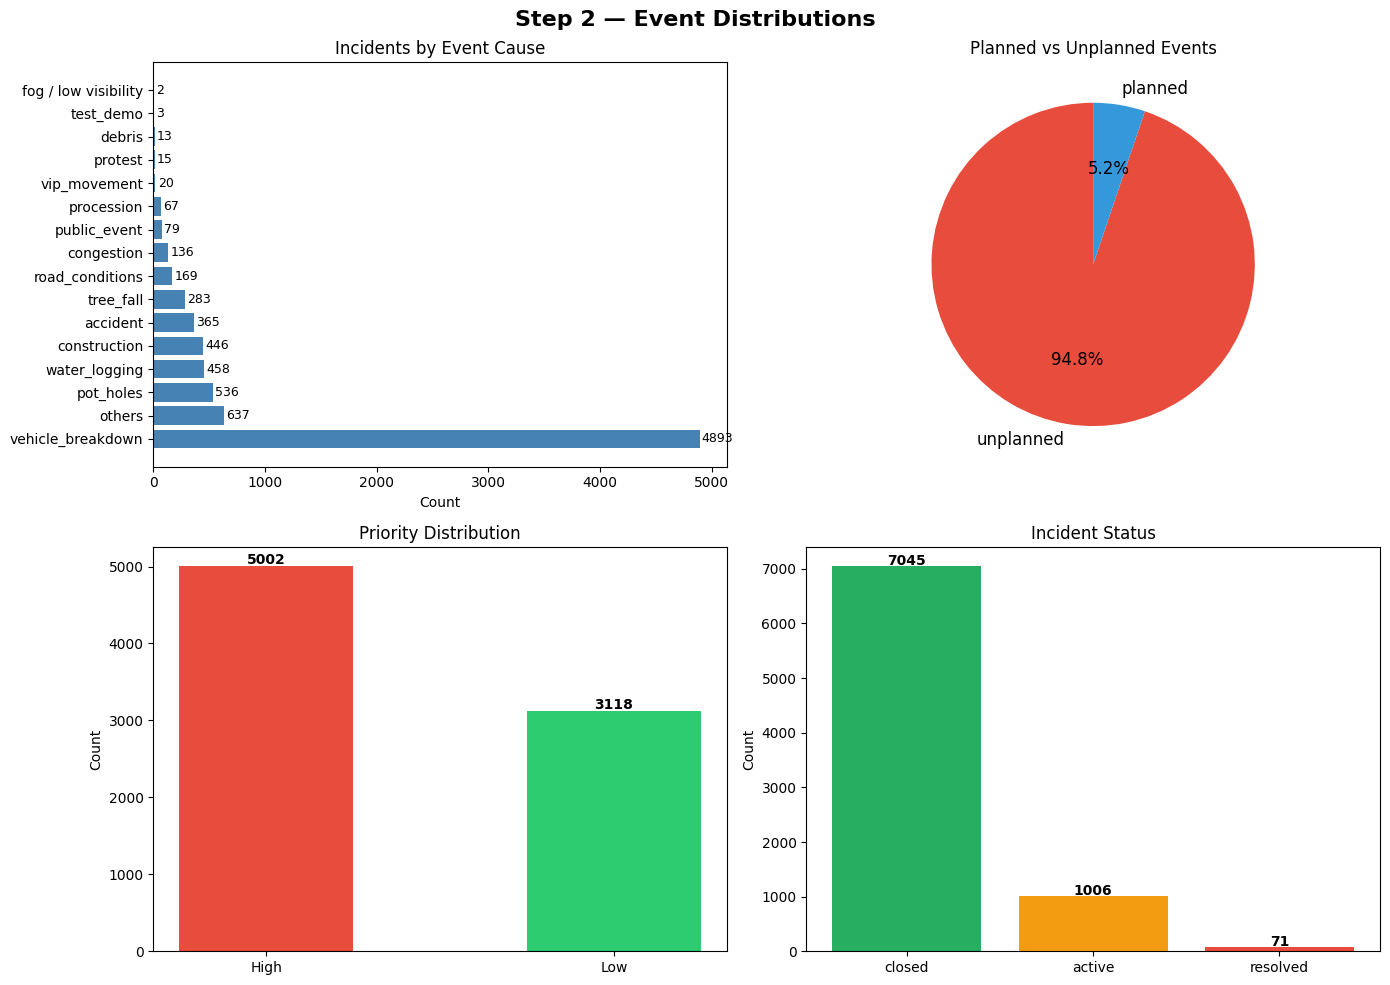

Chart saved as step2_distributions.png


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 2 — Event Distributions', fontsize=16, fontweight='bold')
# ── Chart 1: Event Cause (how many of each type) ─────────────────
cause_counts = temp_df['event_cause'].value_counts()
axes[0,0].barh(cause_counts.index, cause_counts.values, color='steelblue')
axes[0,0].set_title('Incidents by Event Cause')
axes[0,0].set_xlabel('Count')
for i, v in enumerate(cause_counts.values):
    axes[0,0].text(v + 20, i, str(v), va='center', fontsize=9)
# ── Chart 2: Planned vs Unplanned ────────────────────────────────
type_counts = temp_df['event_type'].value_counts()
colors = ['#e74c3c', '#3498db']
axes[0,1].pie(type_counts.values, labels=type_counts.index,
              autopct='%1.1f%%', colors=colors, startangle=90,
              textprops={'fontsize': 12})
axes[0,1].set_title('Planned vs Unplanned Events')
# ── Chart 3: Priority Distribution ───────────────────────────────
priority_counts = temp_df['priority'].value_counts()
bars = axes[1,0].bar(priority_counts.index, priority_counts.values,
                     color=['#e74c3c', '#2ecc71'], width=0.5)
axes[1,0].set_title('Priority Distribution')
axes[1,0].set_ylabel('Count')
for bar in bars:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 30,
                   str(int(bar.get_height())),
                   ha='center', fontweight='bold')
# ── Chart 4: Status Distribution ─────────────────────────────────
status_counts = temp_df['status'].value_counts()
axes[1,1].bar(status_counts.index, status_counts.values,
              color=['#27ae60', '#f39c12', '#e74c3c'])
axes[1,1].set_title('Incident Status')
axes[1,1].set_ylabel('Count')
for i, (idx, val) in enumerate(status_counts.items()):
    axes[1,1].text(i, val + 30, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('step2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as step2_distributions.png")

In [53]:
print("=" * 50)
print("KEY NUMBERS")
print("=" * 50)
print(f"Total incidents       : {len(temp_df):,}")
print(f"Unplanned             : {(temp_df['event_type']=='unplanned').sum():,} ({(temp_df['event_type']=='unplanned').mean()*100:.1f}%)")
print(f"Planned               : {(temp_df['event_type']=='planned').sum():,} ({(temp_df['event_type']=='planned').mean()*100:.1f}%)")
print(f"High Priority         : {(temp_df['priority']=='High').sum():,} ({(temp_df['priority']=='High').mean()*100:.1f}%)")
print(f"Needs Road Closure    : {temp_df['requires_road_closure'].sum():,} ({temp_df['requires_road_closure'].mean()*100:.1f}%)")
print(f"Top cause             : {temp_df['event_cause'].value_counts().index[0]} ({temp_df['event_cause'].value_counts().values[0]:,})")
print(f"Median duration       : {temp_df['duration_hrs'].median():.2f} hours")
print(f"Still active          : {(temp_df['status']=='active').sum():,}")

KEY NUMBERS
Total incidents       : 8,122
Unplanned             : 7,701 (94.8%)
Planned               : 421 (5.2%)
High Priority         : 5,002 (61.6%)
Needs Road Closure    : 660 (8.1%)
Top cause             : vehicle_breakdown (4,893)
Median duration       : 1.08 hours
Still active          : 1,006


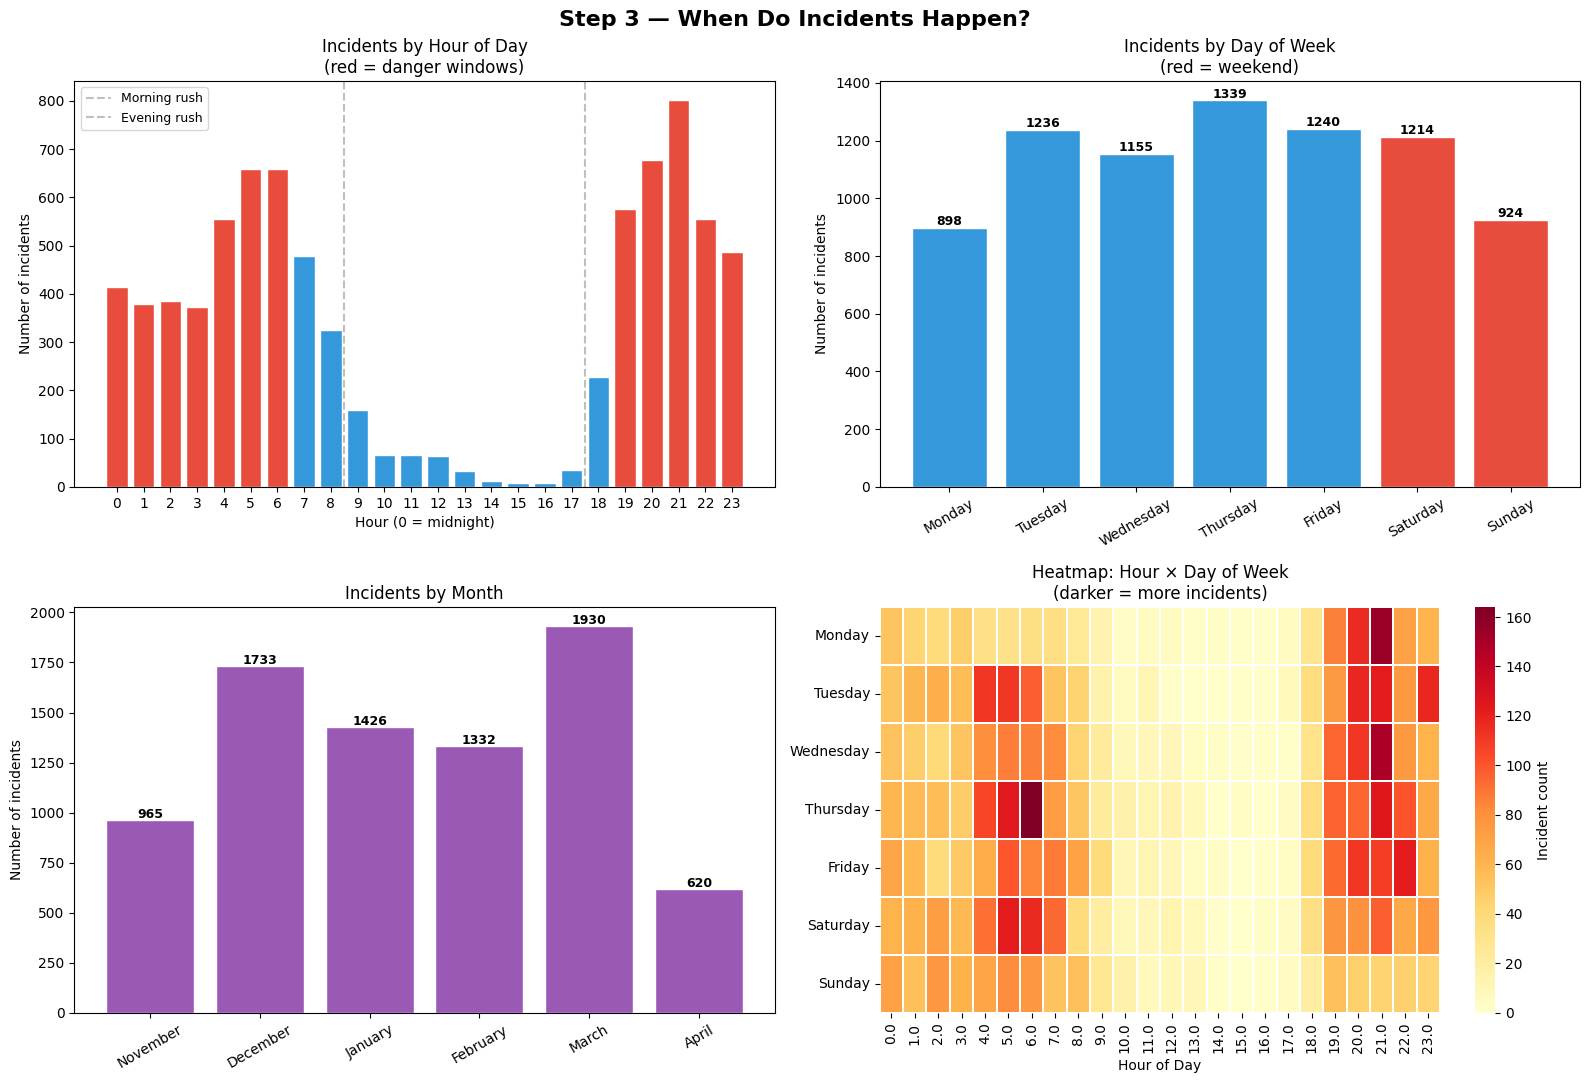

Saved as step3_time_patterns.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Step 3 — When Do Incidents Happen?', fontsize=16, fontweight='bold')
# ── Chart 1: Incidents by Hour of Day ────────────────────────────
hour_counts = temp_df['hour'].value_counts().sort_index()
colors_hour = ['#e74c3c' if h in [4,5,6,19,20,21,22,23,0,1,2,3]
               else '#3498db' for h in hour_counts.index]
axes[0,0].bar(hour_counts.index, hour_counts.values, color=colors_hour, edgecolor='white')
axes[0,0].set_title('Incidents by Hour of Day\n(red = danger windows)', fontsize=12)
axes[0,0].set_xlabel('Hour (0 = midnight)')
axes[0,0].set_ylabel('Number of incidents')
axes[0,0].set_xticks(range(0, 24))
axes[0,0].axvline(x=8.5, color='gray', linestyle='--', alpha=0.5, label='Morning rush')
axes[0,0].axvline(x=17.5, color='gray', linestyle='--', alpha=0.5, label='Evening rush')
axes[0,0].legend(fontsize=9)
# ── Chart 2: Incidents by Day of Week ────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = temp_df['day_of_week'].value_counts().reindex(day_order)
bar_colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in day_order]
axes[0,1].bar(day_counts.index, day_counts.values, color=bar_colors, edgecolor='white')
axes[0,1].set_title('Incidents by Day of Week\n(red = weekend)', fontsize=12)
axes[0,1].set_ylabel('Number of incidents')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(day_counts.values):
    axes[0,1].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')
# ── Chart 3: Incidents by Month ───────────────────────────────────
month_order = ['November','December','January','February','March','April']
month_counts = temp_df['month'].value_counts().reindex(month_order)
axes[1,0].bar(month_counts.index, month_counts.values, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Incidents by Month', fontsize=12)
axes[1,0].set_ylabel('Number of incidents')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(month_counts.values):
    axes[1,0].text(i, v + 10, str(int(v)), ha='center', fontsize=9, fontweight='bold')
# ── Chart 4: Heatmap — Hour vs Day of Week ────────────────────────
pivot = temp_df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order)
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd',
            linewidths=0.3, cbar_kws={'label': 'Incident count'})
axes[1,1].set_title('Heatmap: Hour × Day of Week\n(darker = more incidents)', fontsize=12)
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('')
plt.tight_layout()
plt.savefig('step3_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as step3_time_patterns.png")

In [55]:
print("=" * 50)
print("TIME PATTERN INSIGHTS")
print("=" * 50)

# Peak hours
peak_hours = temp_df['hour'].value_counts().head(5).sort_index()
print("\nTop 5 peak hours:")
print(peak_hours.to_string())

# Busiest day
print(f"\nBusiest day   : {temp_df['day_of_week'].value_counts().index[0]}")
print(f"Quietest day  : {temp_df['day_of_week'].value_counts().index[-1]}")

# Night vs day split
night = temp_df[(temp_df['hour'] >= 20) | (temp_df['hour'] <= 6)].shape[0]
day_  = temp_df[(temp_df['hour'] > 6) & (temp_df['hour'] < 20)].shape[0]
print(f"\nNight incidents (8PM–6AM) : {night:,} ({night/len(temp_df)*100:.1f}%)")
print(f"Day incidents  (6AM–8PM)  : {day_:,} ({day_/len(temp_df)*100:.1f}%)")

# High priority by hour bucket
temp_df['time_bucket'] = pd.cut(temp_df['hour'],
    bins=[0,6,12,18,24],
    labels=['Night (0-6)','Morning (6-12)','Afternoon (12-18)','Evening (18-24)'],
    right=False)
print("\nHigh priority % by time bucket:")
print(temp_df.groupby('time_bucket', observed=True)['priority']
      .apply(lambda x: f"{(x=='High').mean()*100:.1f}%"))


TIME PATTERN INSIGHTS

Top 5 peak hours:
hour
5.0     658
6.0     658
19.0    576
20.0    678
21.0    801

Busiest day   : Thursday
Quietest day  : Monday

Night incidents (8PM–6AM) : 5,944 (73.2%)
Day incidents  (6AM–8PM)  : 2,062 (25.4%)

High priority % by time bucket:
time_bucket
Night (0-6)          65.1%
Morning (6-12)       57.5%
Afternoon (12-18)    57.8%
Evening (18-24)      61.5%
Name: priority, dtype: object


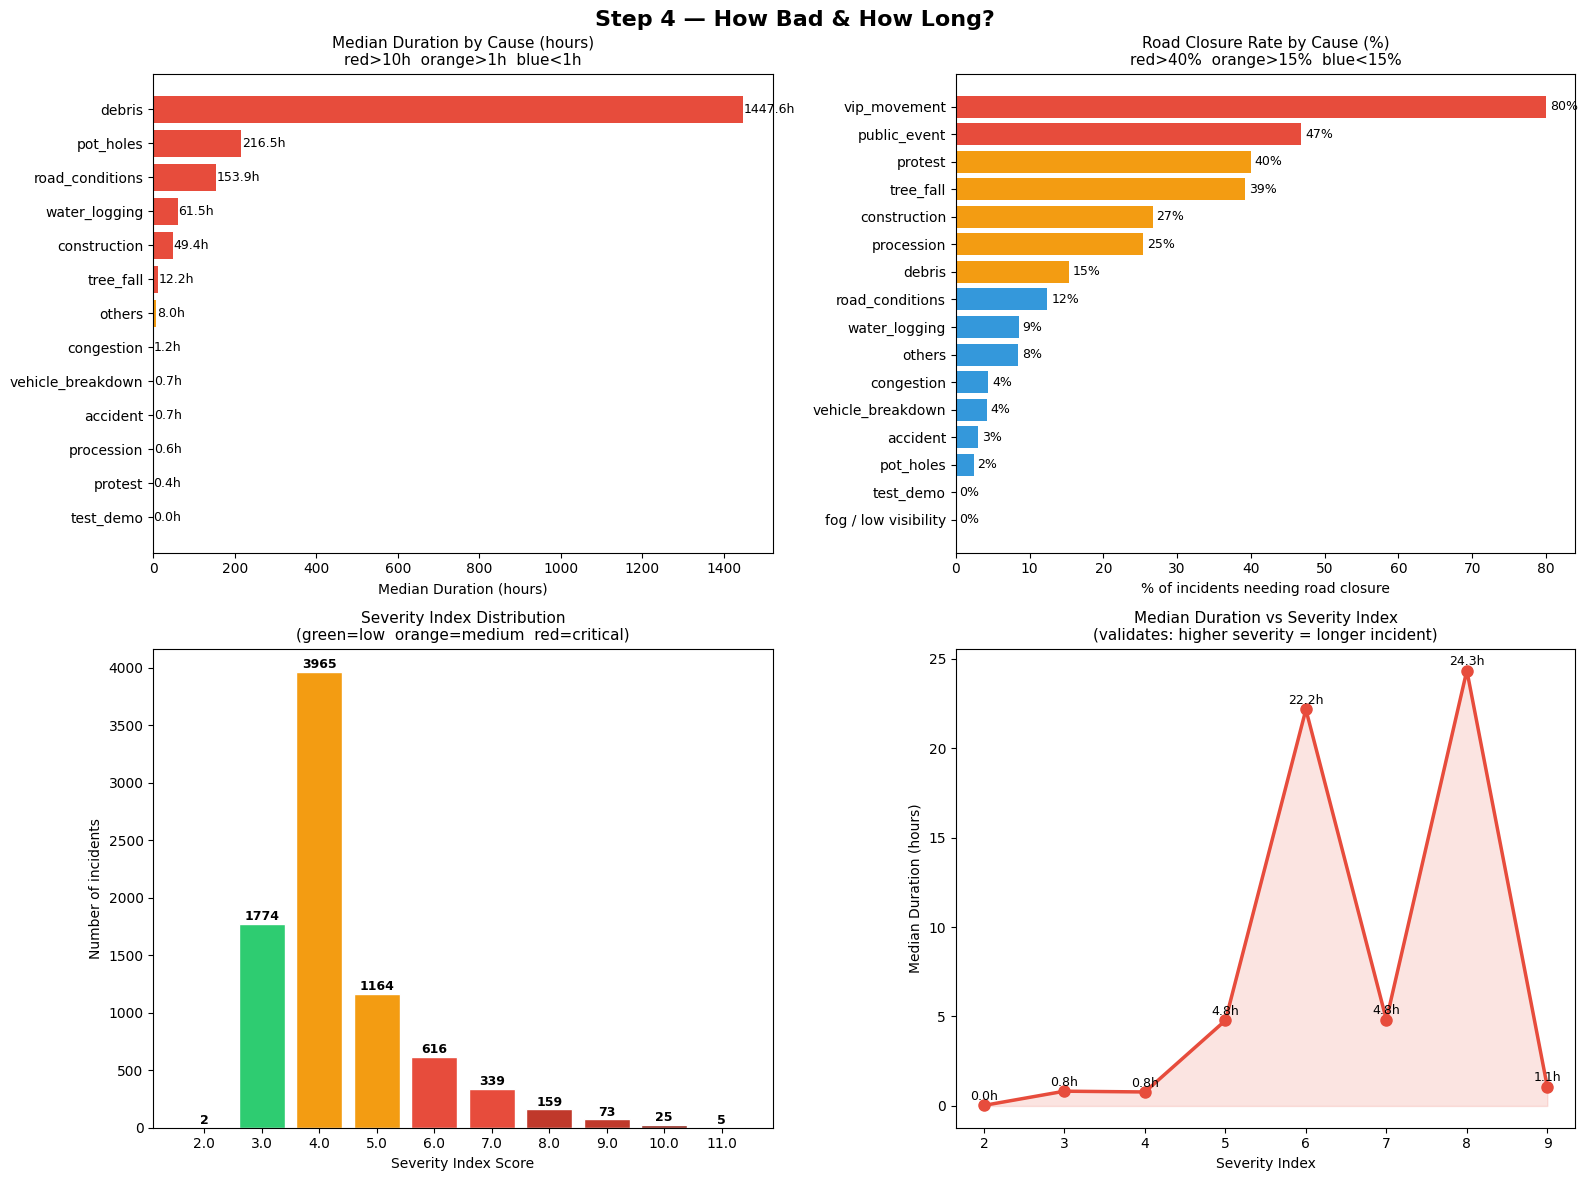

Saved as step4_severity.png


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Step 4 — How Bad & How Long?', fontsize=16, fontweight='bold')

# ── Chart 1: Median Duration by Event Cause ──────────────────────
duration_by_cause = (temp_df.groupby('event_cause')['duration_hrs']
                     .median().sort_values(ascending=True).dropna())

colors_dur = ['#e74c3c' if v > 10 else '#f39c12' if v > 1
              else '#3498db' for v in duration_by_cause.values]
axes[0,0].barh(duration_by_cause.index, duration_by_cause.values, color=colors_dur)
axes[0,0].set_title('Median Duration by Cause (hours)\nred>10h  orange>1h  blue<1h', fontsize=11)
axes[0,0].set_xlabel('Median Duration (hours)')
for i, v in enumerate(duration_by_cause.values):
    axes[0,0].text(v + 0.5, i, f'{v:.1f}h', va='center', fontsize=9)

# ── Chart 2: Road Closure Rate by Event Cause ────────────────────
closure_rate = (temp_df.groupby('event_cause')['requires_road_closure']
                .mean() * 100).sort_values(ascending=True)

colors_cl = ['#e74c3c' if v > 40 else '#f39c12' if v > 15
             else '#3498db' for v in closure_rate.values]
axes[0,1].barh(closure_rate.index, closure_rate.values, color=colors_cl)
axes[0,1].set_title('Road Closure Rate by Cause (%)\nred>40%  orange>15%  blue<15%', fontsize=11)
axes[0,1].set_xlabel('% of incidents needing road closure')
for i, v in enumerate(closure_rate.values):
    axes[0,1].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=9)

# ── Chart 3: Build & Plot Severity Index ─────────────────────────
cause_score_map = {
    'vip_movement':5, 'public_event':4, 'protest':4, 'procession':3,
    'construction':3, 'tree_fall':3, 'water_logging':3, 'debris':3,
    'road_conditions':2, 'congestion':2, 'accident':2, 'others':2,
    'vehicle_breakdown':1, 'pot_holes':1, 'fog / low visibility':1, 'test_demo':0
}
temp_df['cause_score']    = temp_df['event_cause'].map(cause_score_map).fillna(1)
temp_df['type_score']     = temp_df['event_type'].map({'planned':2,'unplanned':1})
temp_df['priority_score'] = temp_df['priority'].map({'High':2,'Low':1}).fillna(1)
temp_df['closure_score']  = temp_df['requires_road_closure'].astype(int) * 2
temp_df['severity_index'] = (temp_df['cause_score'] + temp_df['type_score'] +
                              temp_df['priority_score'] + temp_df['closure_score'])

sev_counts = temp_df['severity_index'].value_counts().sort_index()
axes[1,0].bar(sev_counts.index.astype(str), sev_counts.values,
              color=['#2ecc71','#2ecc71','#f39c12','#f39c12',
                     '#e74c3c','#e74c3c','#c0392b','#c0392b','#922b21'],
              edgecolor='white')
axes[1,0].set_title('Severity Index Distribution\n(green=low  orange=medium  red=critical)', fontsize=11)
axes[1,0].set_xlabel('Severity Index Score')
axes[1,0].set_ylabel('Number of incidents')
for i, (idx, val) in enumerate(sev_counts.items()):
    axes[1,0].text(i, val + 30, str(val), ha='center', fontsize=9, fontweight='bold')

# ── Chart 4: Median Duration by Severity Index ───────────────────
dur_by_sev = temp_df.groupby('severity_index')['duration_hrs'].median().dropna()
axes[1,1].plot(dur_by_sev.index, dur_by_sev.values,
               marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1,1].fill_between(dur_by_sev.index, dur_by_sev.values, alpha=0.15, color='#e74c3c')
axes[1,1].set_title('Median Duration vs Severity Index\n(validates: higher severity = longer incident)', fontsize=11)
axes[1,1].set_xlabel('Severity Index')
axes[1,1].set_ylabel('Median Duration (hours)')
axes[1,1].set_xticks(dur_by_sev.index)
for x, y in zip(dur_by_sev.index, dur_by_sev.values):
    axes[1,1].text(x, y + 0.3, f'{y:.1f}h', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('step4_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as step4_severity.png")

In [57]:
print("=" * 65)
print("SEVERITY → RESOURCE RECOMMENDATION TABLE")
print("=" * 65)

severity_summary = temp_df.groupby('severity_index').agg(
    incident_count   = ('id', 'count'),
    median_duration  = ('duration_hrs', 'median'),
    road_closure_pct = ('requires_road_closure', lambda x: f"{x.mean()*100:.0f}%"),
    high_priority_pct= ('priority', lambda x: f"{(x=='High').mean()*100:.0f}%")
).round(2)

# Add recommended manpower column
manpower_map = {2:1, 3:2, 4:2, 5:3, 6:4, 7:6, 8:8, 9:10, 10:12, 11:15}
severity_summary['suggested_officers'] = [
    manpower_map.get(i, 2) for i in severity_summary.index
]

print(severity_summary.to_string())
print()
print("This table = your manpower recommendation engine backbone!")

SEVERITY → RESOURCE RECOMMENDATION TABLE
                incident_count  median_duration road_closure_pct high_priority_pct  suggested_officers
severity_index                                                                                        
2.0                          2             0.03               0%                0%                   1
3.0                       1774             0.83               0%                0%                   2
4.0                       3965             0.78               0%               87%                   2
5.0                       1164             4.78              10%               59%                   3
6.0                        616            22.16              24%               83%                   4
7.0                        339             4.81              49%               60%                   6
8.0                        159            24.34              81%               63%                   8
9.0                         73  

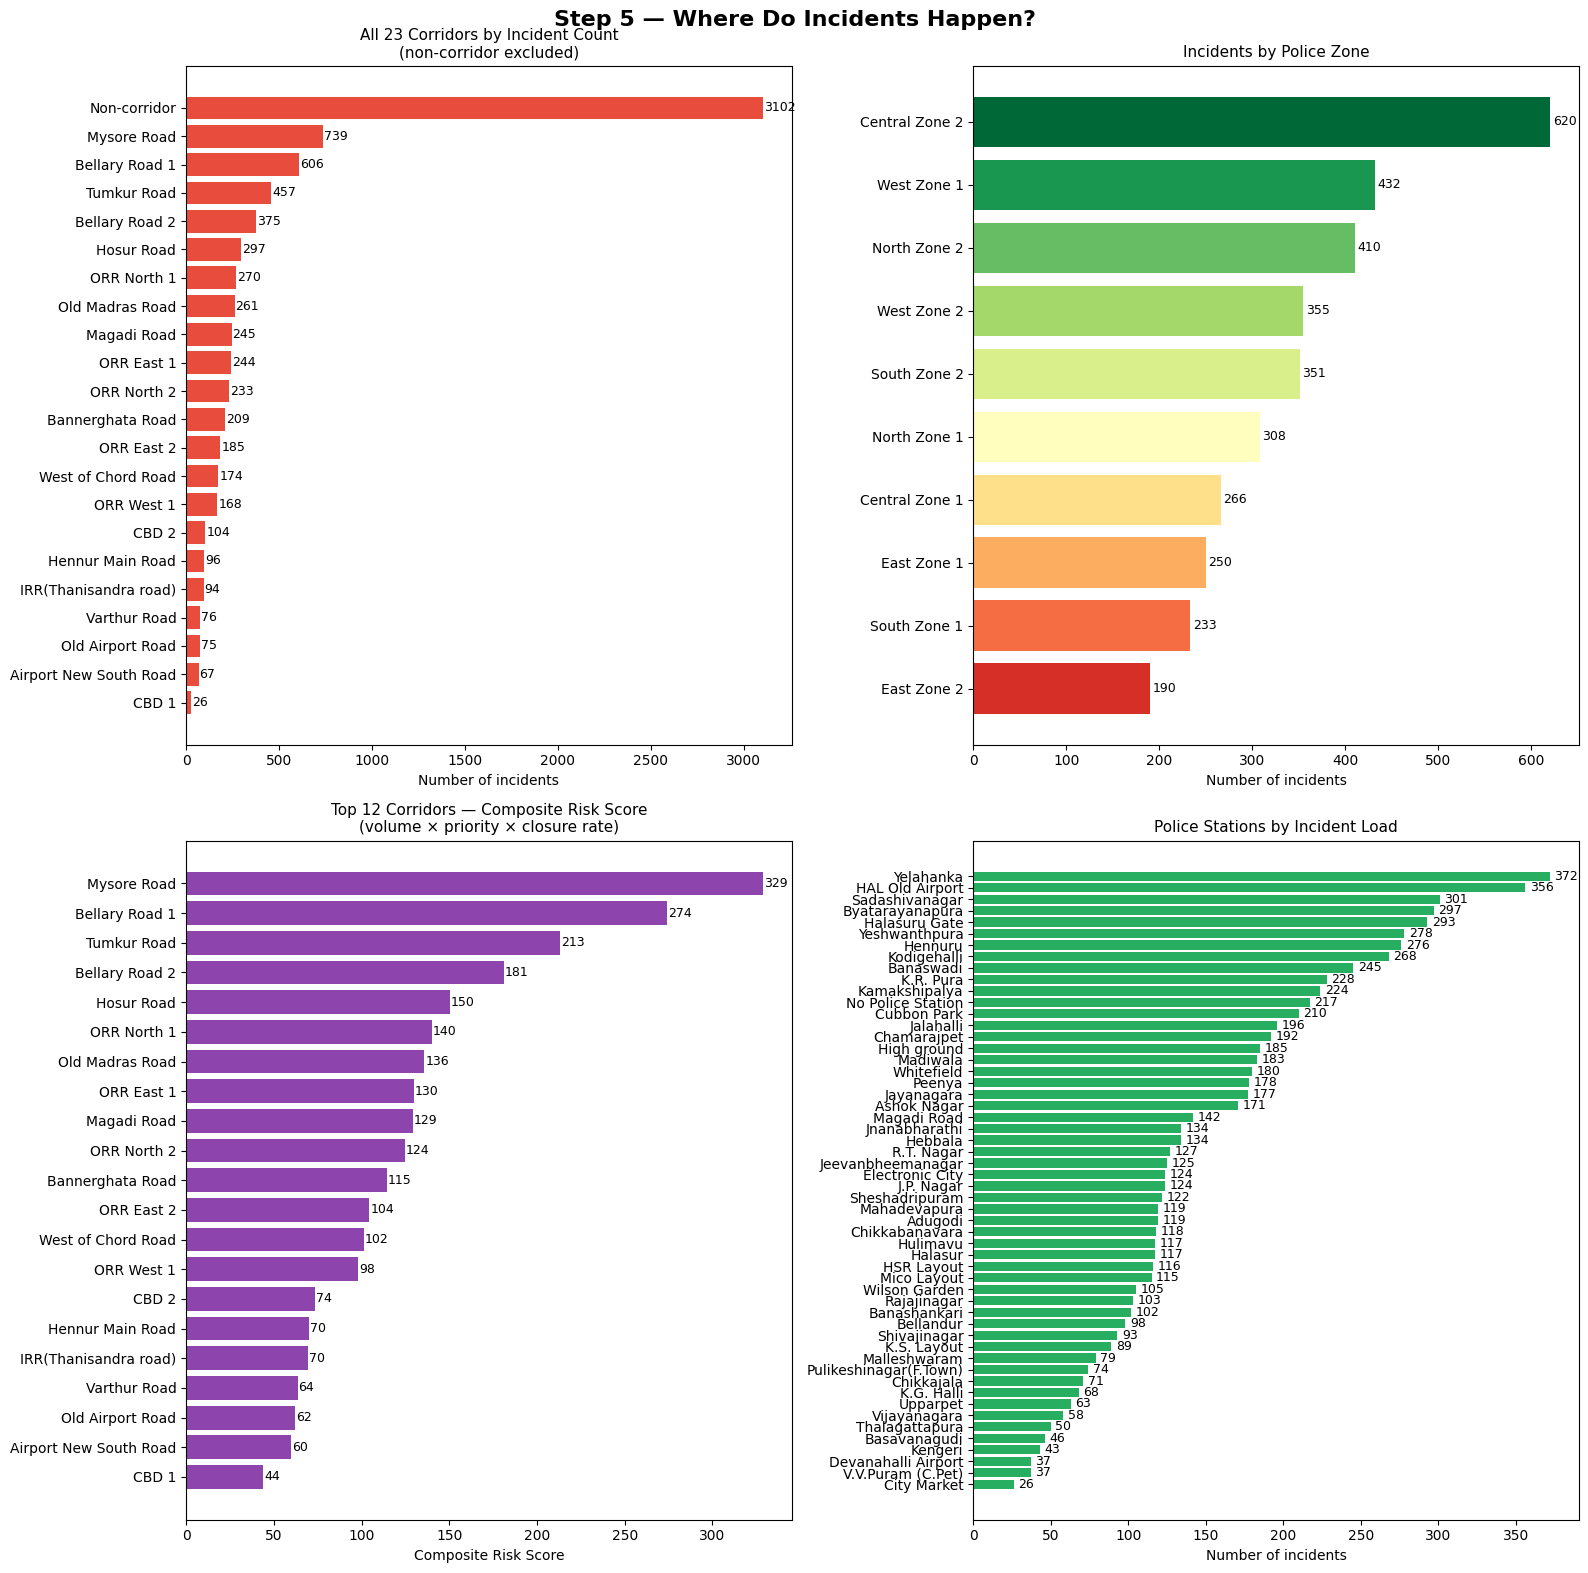

Saved as step5_corridors_zones.png


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.suptitle('Step 5 — Where Do Incidents Happen?', fontsize=16, fontweight='bold')

# ── Chart 1: Corridors by Incident Count ──────────────────
corridor_counts = (temp_df[temp_df['corridor'] != 'non-corridor']
                   ['corridor'].value_counts())
axes[0,0].barh(corridor_counts.index[::-1], corridor_counts.values[::-1],
               color='#e74c3c')
axes[0,0].set_title('All 23 Corridors by Incident Count\n(non-corridor excluded)', fontsize=11)
axes[0,0].set_xlabel('Number of incidents')
for i, v in enumerate(corridor_counts.values[::-1]):
    axes[0,0].text(v + 5, i, str(v), va='center', fontsize=9)

# ── Chart 2: Zone-wise Incident Count ────────────────────────────
zone_counts = temp_df['zone'].value_counts().dropna()
colors_zone = plt.cm.RdYlGn_r(
    [i/len(zone_counts) for i in range(len(zone_counts))])
axes[0,1].barh(zone_counts.index[::-1], zone_counts.values[::-1],
               color=colors_zone[::-1])
axes[0,1].set_title('Incidents by Police Zone', fontsize=11)
axes[0,1].set_xlabel('Number of incidents')
for i, v in enumerate(zone_counts.values[::-1]):
    axes[0,1].text(v + 3, i, str(v), va='center', fontsize=9)

# ── Chart 3: Corridor Severity Score (composite) ─────────────────
corridor_df = temp_df[temp_df['corridor'].notna() &
                      (temp_df['corridor'].str.lower() != 'non-corridor')]
corridor_severity = corridor_df.groupby('corridor').agg(
    count=('id','count'),
    high_prio_pct=('priority', lambda x: (x=='High').mean()),
    closure_pct=('requires_road_closure','mean'),
    avg_severity=('severity_index','mean')
).query('count >= 20')

corridor_severity['composite_score'] = (
    corridor_severity['count'] * 0.4 +
    corridor_severity['high_prio_pct'] * 100 * 0.3 +
    corridor_severity['closure_pct'] * 100 * 0.3
).round(1)

top_corridors = corridor_severity.nlargest(25, 'composite_score')
axes[1,0].barh(top_corridors.index[::-1],
               top_corridors['composite_score'].values[::-1],
               color='#8e44ad')
axes[1,0].set_title('Top 12 Corridors — Composite Risk Score\n(volume × priority × closure rate)', fontsize=11)
axes[1,0].set_xlabel('Composite Risk Score')
for i, v in enumerate(top_corridors['composite_score'].values[::-1]):
    axes[1,0].text(v + 0.5, i, f'{v:.0f}', va='center', fontsize=9)

# ── Chart 4: Police Station Load ─────────────────────────────────
station_counts = temp_df['police_station'].value_counts()
axes[1,1].barh(station_counts.index[::-1], station_counts.values[::-1],
               color='#27ae60')
axes[1,1].set_title('Police Stations by Incident Load', fontsize=11)
axes[1,1].set_xlabel('Number of incidents')
for i, v in enumerate(station_counts.values[::-1]):
    axes[1,1].text(v + 3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('step5_corridors_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as step5_corridors_zones.png")

In [59]:
corridor_severity

,count,high_prio_pct,closure_pct,avg_severity,composite_score
corridor,,,,,
Airport New South Road,67,1.000000,0.104478,5.402985,59.9
Bannerghata Road,209,1.000000,0.033493,4.650718,114.6
Bellary Road 1,606,1.000000,0.054455,4.448845,274.0
Bellary Road 2,375,1.000000,0.032000,4.469333,181.0
CBD 1,26,1.000000,0.115385,4.692308,43.9
CBD 2,104,1.000000,0.067308,4.836538,73.6
Hennur Main Road,96,1.000000,0.062500,5.041667,70.3
Hosur Road,297,1.000000,0.057239,4.437710,150.5
IRR(Thanisandra road),94,1.000000,0.063830,4.744681,69.5


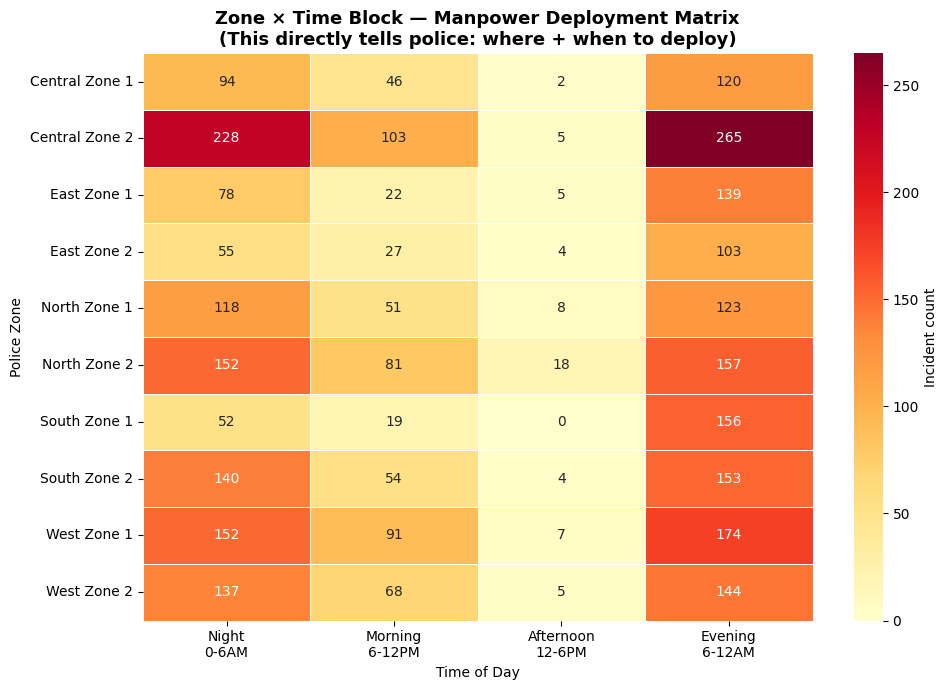

Saved as step5_zone_time_matrix.png


In [62]:
# Zone × Time bucket heatmap (manpower planning matrix)
zone_time = temp_df.dropna(subset=['zone']).copy()
zone_time
zone_time['time_block'] = pd.cut(
    zone_time['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night\n0-6AM', 'Morning\n6-12PM', 'Afternoon\n12-6PM', 'Evening\n6-12AM'],
    right=False
)

pivot_zt = (zone_time.groupby(['zone', 'time_block'], observed=True)
            .size().unstack(fill_value=0))

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_zt, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Incident count'})
plt.title('Zone × Time Block — Manpower Deployment Matrix\n(This directly tells police: where + when to deploy)',
          fontsize=13, fontweight='bold')
plt.ylabel('Police Zone')
plt.xlabel('Time of Day')
plt.tight_layout()
plt.savefig('step5_zone_time_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as step5_zone_time_matrix.png")

In [63]:
pivot_zt = (zone_time.groupby(['zone', 'time_block'], observed=True).size().unstack(fill_value=0))
pivot_zt

time_block,Night\n0-6AM,Morning\n6-12PM,Afternoon\n12-6PM,Evening\n6-12AM
zone,,,,
Central Zone 1,94,46,2,120
Central Zone 2,228,103,5,265
East Zone 1,78,22,5,139
East Zone 2,55,27,4,103
North Zone 1,118,51,8,123
North Zone 2,152,81,18,157
South Zone 1,52,19,0,156
South Zone 2,140,54,4,153
West Zone 1,152,91,7,174


In [65]:
print("=" * 70)
print("CORRIDOR RISK RANKING — Top 10")
print("=" * 70)
print(top_corridors[['count','high_prio_pct','closure_pct',
                      'avg_severity','composite_score']]
      .nlargest(23,'composite_score')
      .rename(columns={
          'count':'incidents',
          'high_prio_pct':'% high priority',
          'closure_pct':'% road closure',
          'avg_severity':'avg severity',
          'composite_score':'RISK SCORE'
      }).round(2).to_string())

CORRIDOR RISK RANKING — Top 10
                        incidents  % high priority  % road closure  avg severity  RISK SCORE
corridor                                                                                    
Mysore Road                   739             1.00            0.11          4.60       328.7
Bellary Road 1                606             1.00            0.05          4.45       274.0
Tumkur Road                   457             0.99            0.03          4.26       213.3
Bellary Road 2                375             1.00            0.03          4.47       181.0
Hosur Road                    297             1.00            0.06          4.44       150.5
ORR North 1                   270             1.00            0.07          4.78       140.1
Old Madras Road               261             1.00            0.05          4.47       135.8
ORR East 1                    244             1.00            0.07          4.62       129.8
Magadi Road                   245      

In [66]:
temp_df['corridor'].unique()

array(['Tumkur Road', 'ORR East 1', 'Non-corridor', 'CBD 2', 'ORR East 2',
       'ORR West 1', 'ORR North 1', 'Old Madras Road', 'Bellary Road 2',
       'Bellary Road 1', 'Hosur Road', nan, 'Bannerghata Road',
       'ORR North 2', 'Magadi Road', 'IRR(Thanisandra road)',
       'Mysore Road', 'West of Chord Road', 'CBD 1', 'Old Airport Road',
       'Hennur Main Road', 'Airport New South Road', 'Varthur Road'],
      dtype=object)

In [67]:
!pip install folium

In [68]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# ── Base data: drop rows without coordinates ──────────────────────
map_df = temp_df.dropna(subset=['latitude','longitude']).copy()
map_df = map_df[
    (map_df['latitude'].between(12.8, 13.3)) &
    (map_df['longitude'].between(77.3, 77.9))
]  # Keep only valid Bengaluru coordinates
print(f"Plotting {len(map_df):,} incidents on map")

# ── Create base map centered on Bengaluru ────────────────────────
m = folium.Map(
    location=[12.9716, 77.5946],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# ── Layer 1: Heatmap of ALL incidents ────────────────────────────
heat_data = map_df[['latitude','longitude']].values.tolist()
HeatMap(
    heat_data,
    radius=12,
    blur=15,
    max_zoom=13,
    gradient={0.2:'blue', 0.5:'yellow', 0.8:'orange', 1.0:'red'}
).add_to(m)

# ── Layer 2: High severity incidents as red markers ───────────────
high_sev = map_df[map_df['severity_index'] >= 7]
for _, row in high_sev.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='red',
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Cause:</b> {row['event_cause']}<br>"
            f"<b>Severity:</b> {row['severity_index']}<br>"
            f"<b>Corridor:</b> {row['corridor']}<br>"
            f"<b>Zone:</b> {row['zone']}<br>"
            f"<b>Status:</b> {row['status']}",
            max_width=250
        )
    ).add_to(m)

# ── Layer 3: Road closure incidents as orange markers ────────────
closures = map_df[map_df['requires_road_closure'] == True]
for _, row in closures.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='orange',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>ROAD CLOSURE</b><br>"
            f"<b>Cause:</b> {row['event_cause']}<br>"
            f"<b>Corridor:</b> {row['corridor']}<br>"
            f"<b>Zone:</b> {row['zone']}",
            max_width=250
        )
    ).add_to(m)

# ── Add legend ────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:rgba(0,0,0,0.8); padding:15px; border-radius:8px;
     color:white; font-size:13px; font-family:Arial;">
  <b>Bengaluru Traffic Incidents</b><br><br>
  <span style="color:red">●</span> High severity (index ≥ 7)<br>
  <span style="color:orange">●</span> Road closure required<br>
  <span style="background:linear-gradient(to right,blue,yellow,orange,red);
        width:80px; height:10px; display:inline-block;
        vertical-align:middle; border-radius:3px;"></span> All incident density
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Save ──────────────────────────────────────────────────────────
m.save('bengaluru_hotspot_map.html')
print("✅ Map saved as bengaluru_hotspot_map.html")
print("   Open this file in your browser — click any red/orange dot!")

Plotting 8,122 incidents on map
✅ Map saved as bengaluru_hotspot_map.html
   Open this file in your browser — click any red/orange dot!


In [69]:
print("=" * 60)
print("TOP 10 HOTSPOT JUNCTIONS (where to place barricades)")
print("=" * 60)

# By junction name
junc = (temp_df.dropna(subset=['junction'])
        .groupby('junction').agg(
            incidents=('id','count'),
            road_closures=('requires_road_closure','sum'),
            avg_severity=('severity_index','mean')
        ).nlargest(10, 'incidents').round(2))
print(junc.to_string())

print("\n" + "=" * 60)
print("TOP 10 GPS HOTSPOT CLUSTERS")
print("=" * 60)

# Round coordinates to 2 decimal places to cluster nearby incidents
map_df['lat_r'] = map_df['latitude'].round(2)
map_df['lon_r'] = map_df['longitude'].round(2)
gps_clusters = (map_df.groupby(['lat_r','lon_r'])
                .agg(incidents=('id','count'),
                     avg_severity=('severity_index','mean'))
                .nlargest(10, 'incidents').round(2))
print(gps_clusters.to_string())

TOP 10 HOTSPOT JUNCTIONS (where to place barricades)
                           incidents  road_closures  avg_severity
junction                                                         
MekhriCircle                      64              1          4.16
AyyappaTempleJunc                 49              1          4.04
SatteliteBusStandJunc             43              1          4.09
YeshwanthpuraCircle               38              1          4.18
SilkBoardJunc                     33              4          4.64
toll gate mysore road             33              2          4.30
JalahalliCross(SM Circle)         32              0          4.09
Nagavara-ORR Junction             32              2          5.00
YelhankaCircle                    32              0          4.44
K R Circle                        31              9          4.19

TOP 10 GPS HOTSPOT CLUSTERS
             incidents  avg_severity
lat_r lon_r                         
13.00 77.58        137          4.36
12.97 77.70    

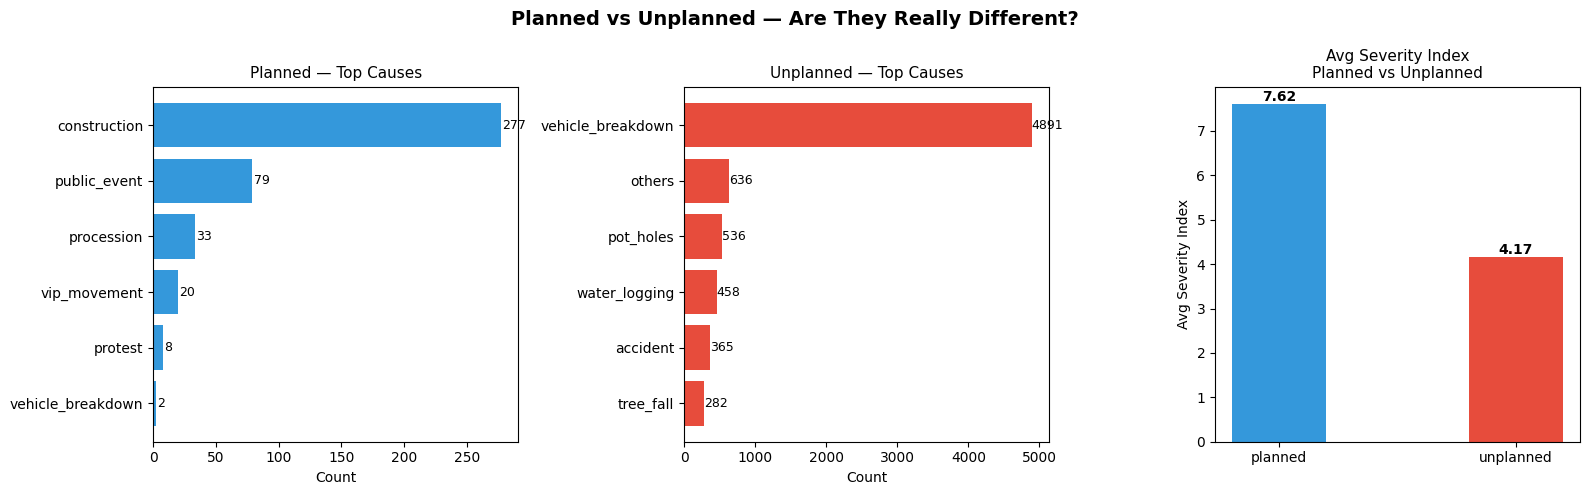

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Planned vs Unplanned — Are They Really Different?',
             fontsize=14, fontweight='bold')

# Chart 1: Top causes within each type
for ax, etype, color in zip(axes[:2],
                             ['planned','unplanned'],
                             ['#3498db','#e74c3c']):
    counts = (temp_df[temp_df['event_type']==etype]
              ['event_cause'].value_counts().head(6))
    ax.barh(counts.index[::-1], counts.values[::-1], color=color)
    ax.set_title(f'{etype.capitalize()} — Top Causes', fontsize=11)
    ax.set_xlabel('Count')
    for i, v in enumerate(counts.values[::-1]):
        ax.text(v+1, i, str(v), va='center', fontsize=9)

# Chart 3: Avg severity comparison
sev_compare = temp_df.groupby('event_type')['severity_index'].mean()
axes[2].bar(sev_compare.index, sev_compare.values,
            color=['#3498db','#e74c3c'], width=0.4)
axes[2].set_title('Avg Severity Index\nPlanned vs Unplanned', fontsize=11)
axes[2].set_ylabel('Avg Severity Index')
for i, (idx, val) in enumerate(sev_compare.items()):
    axes[2].text(i, val+0.05, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_extra1_planned_vs_unplanned.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
print("=" * 65)
print("FEATURE READINESS SUMMARY — What goes into ML models")
print("=" * 65)

features = {
    'event_type'           : ('categorical', temp_df['event_type'].isna().sum(), 'encode → 0/1'),
    'event_cause'          : ('categorical', temp_df['event_cause'].isna().sum(), 'label encode'),
    'priority'             : ('TARGET ⭐',   temp_df['priority'].isna().sum(),   'Model 1 target'),
    'requires_road_closure': ('TARGET ⭐',   0,                                  'Model 2 target'),
    'duration_hrs'         : ('TARGET ⭐',   temp_df['duration_hrs'].isna().sum(),'Model 3 target'),
    'severity_index'       : ('engineered',  0,                                  'key input feature'),
    'hour'                 : ('numeric',     temp_df['hour'].isna().sum(),        'keep as-is'),
    'day_of_week'          : ('categorical', temp_df['day_of_week'].isna().sum(), 'label encode'),
    'month_num'            : ('numeric',     temp_df['month_num'].isna().sum(),   'keep as-is'),
    'corridor'             : ('categorical', temp_df['corridor'].isna().sum(),    'label encode'),
    'zone'                 : ('categorical', temp_df['zone'].isna().sum(),        'label encode'),
    'police_station'       : ('categorical', 0,                                  'label encode'),
    'veh_type'             : ('categorical', temp_df['veh_type'].isna().sum(),    'fill null → unknown'),
    'cause_score'          : ('engineered',  0,                                  'key input feature'),
    'type_score'           : ('engineered',  0,                                  'key input feature'),
}

print(f"{'Feature':<25} {'Type':<15} {'Nulls':<8} {'Action'}")
print("-" * 65)
for feat, (ftype, nulls, action) in features.items():
    print(f"{feat:<25} {ftype:<15} {nulls:<8} {action}")

print()
print(f"Total usable features for ML : {len(features)}")
print(f"Target variables             : 3 (priority, road_closure, duration)")
print(f"Rows available for training  : {temp_df.dropna(subset=['priority']).shape[0]:,}")

FEATURE READINESS SUMMARY — What goes into ML models
Feature                   Type            Nulls    Action
-----------------------------------------------------------------
event_type                categorical     0        encode → 0/1
event_cause               categorical     0        label encode
priority                  TARGET ⭐        2        Model 1 target
requires_road_closure     TARGET ⭐        0        Model 2 target
duration_hrs              TARGET ⭐        4997     Model 3 target
severity_index            engineered      0        key input feature
hour                      numeric         116      keep as-is
day_of_week               categorical     116      label encode
month_num                 numeric         116      keep as-is
corridor                  categorical     19       label encode
zone                      categorical     4707     label encode
police_station            categorical     0        label encode
veh_type                  categorical     3237  

In [72]:
print("=" * 65)
print("FINAL NULL HANDLING + LEAKAGE FIX")
print("=" * 65)

# 1. Drop the 2 rows with missing priority (can't train/predict on these)
before = len(temp_df)
temp_df = temp_df.dropna(subset=['priority'])
print(f"Dropped {before - len(temp_df)} rows with missing priority")

# 2. Fill veh_type nulls
temp_df['veh_type'] = temp_df['veh_type'].fillna('unknown')

# 3. Fill zone nulls
temp_df['zone'] = temp_df['zone'].fillna('Unknown')

# 4. LEAKAGE CHECK — severity_index was built FROM priority_score and closure_score,
#    which are direct functions of our two classification targets (priority, requires_road_closure).
#    If we feed severity_index/priority_score/closure_score into those models, they'll
#    just be decoding their own answer — accuracy will look great and mean nothing.
#    Keep severity_index ONLY for EDA / duration regression (duration isn't a component of it).
LEAKY_COLS = ['priority_score', 'closure_score']
print(f"\nExcluding from classifier features (data leakage): {LEAKY_COLS}")
print("severity_index kept ONLY for duration regression, NOT for priority/closure models")

print(f"\nFinal temp_df shape: {temp_df.shape}")
print(f"Nulls remaining in key features:")
print(temp_df[['event_type','event_cause','zone','corridor','veh_type','police_station']].isnull().sum())

FINAL NULL HANDLING + LEAKAGE FIX
Dropped 2 rows with missing priority

Excluding from classifier features (data leakage): ['priority_score', 'closure_score']
severity_index kept ONLY for duration regression, NOT for priority/closure models

Final temp_df shape: (8120, 38)
Nulls remaining in key features:
event_type         0
event_cause        0
zone               0
corridor          19
veh_type           0
police_station     0
dtype: int64


In [73]:
print("=" * 65)
print("BUILDING FEATURE MATRIX")
print("=" * 65)

from sklearn.preprocessing import OneHotEncoder

# Categorical features — nominal, no inherent order → one-hot, NOT label encode
# (label encoding corridor/zone/police_station would imply a false ranking)
CAT_FEATURES = ['event_type', 'event_cause', 'zone', 'corridor', 'veh_type']

# Numerical features (cause_score/type_score dropped — redundant with the raw category)
NUM_FEATURES = ['latitude', 'longitude', 'hour', 'month_num']

# Derived time flags (cheap to add, often boost tree models)
temp_df['is_weekend']   = temp_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
temp_df['is_peak_hour'] = temp_df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
temp_df['is_night']     = ((temp_df['hour'] >= 22) | (temp_df['hour'] < 6)).astype(int)
NUM_FEATURES += ['is_weekend', 'is_peak_hour', 'is_night']

FEATURE_COLS = CAT_FEATURES + NUM_FEATURES
print(f"Categorical: {CAT_FEATURES}")
print(f"Numerical:   {NUM_FEATURES}")

# Build model_df — only rows with no nulls in chosen features
model_df = temp_df.dropna(subset=FEATURE_COLS + ['priority', 'requires_road_closure']).copy()
print(f"\nRows usable for modeling: {len(model_df)} (out of {len(temp_df)})")

# One-hot encode categoricals
model_df_encoded = pd.get_dummies(model_df[FEATURE_COLS], columns=CAT_FEATURES, drop_first=False)
print(f"Shape after one-hot encoding: {model_df_encoded.shape}")
print(f"\nSample encoded columns: {model_df_encoded.columns[:10].tolist()}")

BUILDING FEATURE MATRIX
Categorical: ['event_type', 'event_cause', 'zone', 'corridor', 'veh_type']
Numerical:   ['latitude', 'longitude', 'hour', 'month_num', 'is_weekend', 'is_peak_hour', 'is_night']

Rows usable for modeling: 7987 (out of 8120)
Shape after one-hot encoding: (7987, 69)

Sample encoded columns: ['latitude', 'longitude', 'hour', 'month_num', 'is_weekend', 'is_peak_hour', 'is_night', 'event_type_planned', 'event_type_unplanned', 'event_cause_accident']


In [74]:
!pip install xgboost imbalanced-learn -q
print("Libraries ready")

Libraries ready


In [76]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score


MODEL 1 — PRIORITY CLASSIFIER (leak-fixed, corridor excluded)
Rows usable: 8006
Class balance: {1: 4946, 0: 3060}
Train: (6404, 47)  Test: (1602, 47)

Accuracy: 0.7697
F1: 0.8171

              precision    recall  f1-score   support

         Low       0.71      0.67      0.69       612
        High       0.80      0.83      0.82       990

    accuracy                           0.77      1602
   macro avg       0.76      0.75      0.75      1602
weighted avg       0.77      0.77      0.77      1602

best_priority_model captured ✅   priority_feature_cols captured (47 features) ✅


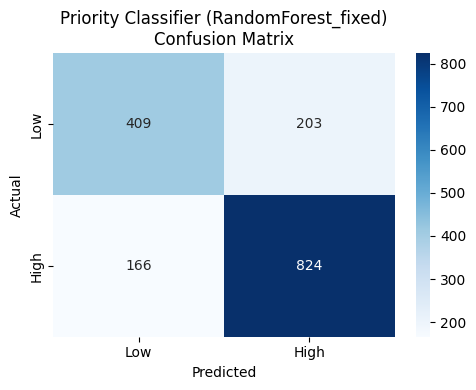

Saved as model1_confusion_matrix.png


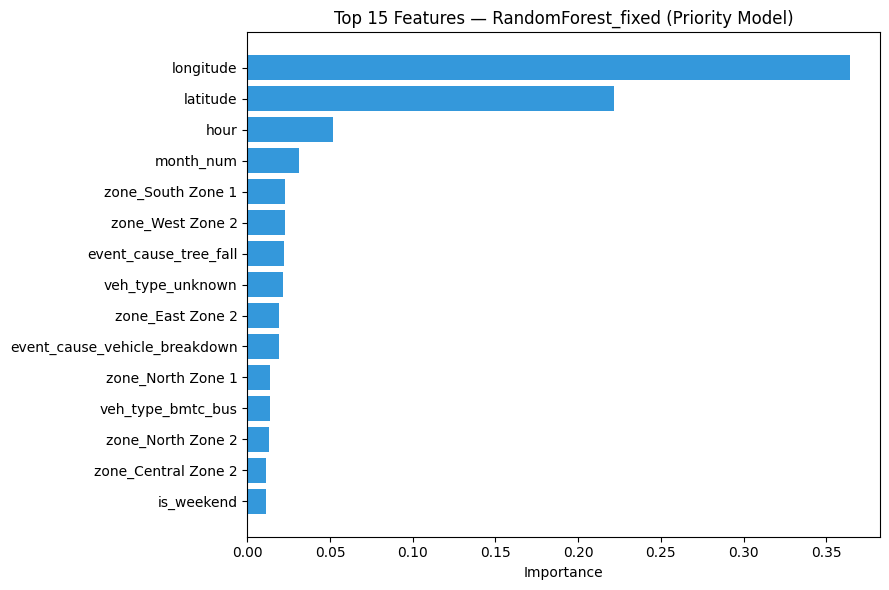

Saved as model1_feature_importance.png


In [125]:
print("=" * 65)
print("MODEL 1 — PRIORITY CLASSIFIER (leak-fixed, corridor excluded)")
print("=" * 65)
CAT_FEATURES_FIXED = ['event_type', 'event_cause', 'zone', 'veh_type']   # corridor excluded — leak source
NUM_FEATURES_FIXED = ['latitude', 'longitude', 'hour', 'month_num',
                       'is_weekend', 'is_peak_hour', 'is_night']

priority_df = temp_df.dropna(subset=CAT_FEATURES_FIXED + NUM_FEATURES_FIXED + ['priority']).copy()
X_fixed = pd.get_dummies(priority_df[CAT_FEATURES_FIXED + NUM_FEATURES_FIXED], columns=CAT_FEATURES_FIXED)
y_fixed = (priority_df['priority'] == 'High').astype(int)

print(f"Rows usable: {len(priority_df)}")
print(f"Class balance: {y_fixed.value_counts().to_dict()}")

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fixed, y_fixed, test_size=0.2, random_state=42, stratify=y_fixed
)
print(f"Train: {X_train_f.shape}  Test: {X_test_f.shape}")

priority_clf_fixed = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
priority_clf_fixed.fit(X_train_f, y_train_f)
pred_f = priority_clf_fixed.predict(X_test_f)

acc = accuracy_score(y_test_f, pred_f)
f1 = f1_score(y_test_f, pred_f)
print(f"\nAccuracy: {acc:.4f}")
print(f"F1: {f1:.4f}")
print()
print(classification_report(y_test_f, pred_f, target_names=['Low', 'High']))

# Names the recommendation engine and gather script both expect
best_priority_model = priority_clf_fixed
priority_feature_cols = list(X_fixed.columns)
best_priority_name = 'RandomForest_fixed'

print(f"best_priority_model captured ✅   priority_feature_cols captured ({len(priority_feature_cols)} features) ✅")

# --- Confusion matrix ---
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_f, pred_f)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], ax=ax)
ax.set_title(f'Priority Classifier ({best_priority_name})\nConfusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model1_confusion_matrix.png")

# --- Feature importance ---
fi = pd.Series(priority_clf_fixed.feature_importances_, index=X_fixed.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi.index[::-1], fi.values[::-1], color='#3498db')
ax.set_title(f'Top 15 Features — {best_priority_name} (Priority Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('model1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model1_feature_importance.png")

MODEL 2 — ROAD CLOSURE CLASSIFIER
Rows usable: 7987
Class balance: {0: 7407, 1: 580}  (7.3% require closure)
Train: (6389, 69)  Test: (1598, 69)
scale_pos_weight (for XGBoost) = 12.77

[RandomForest]  Accuracy=0.8642  F1=0.3522

[XGBoost]  Accuracy=0.8542  F1=0.2918

★ Best model (default threshold=0.5): RandomForest
              precision    recall  f1-score   support

  No Closure       0.96      0.89      0.92      1482
     Closure       0.27      0.51      0.35       116

    accuracy                           0.86      1598
   macro avg       0.61      0.70      0.64      1598
weighted avg       0.91      0.86      0.88      1598

THRESHOLD TUNING
Default threshold (0.5) F1: 0.3522
Optimal threshold: 0.567  ->  F1: 0.3951
At this threshold: Precision=0.378  Recall=0.414

              precision    recall  f1-score   support

  No Closure       0.95      0.95      0.95      1482
     Closure       0.38      0.41      0.40       116

    accuracy                           0.91    

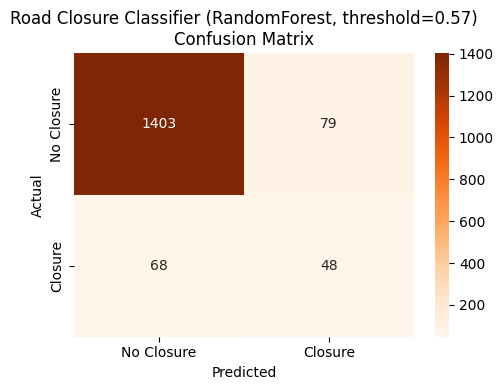

Saved as model2_confusion_matrix.png

closure_feature_cols captured: 69 features
best_threshold captured: 0.567


In [127]:
print("=" * 65)
print("MODEL 2 — ROAD CLOSURE CLASSIFIER")
print("=" * 65)

# Self-contained feature build — does NOT reuse the `X` variable from the
# priority model cell, since that one excludes corridor. corridor is fine
# here (it correlates with closure ~88-97%, not a 1:1 leak like with priority).
CAT_FEATURES = ['event_type', 'event_cause', 'zone', 'corridor', 'veh_type']
NUM_FEATURES = ['latitude', 'longitude', 'hour', 'month_num',
                 'is_weekend', 'is_peak_hour', 'is_night']

closure_df = temp_df.dropna(subset=CAT_FEATURES + NUM_FEATURES + ['requires_road_closure']).copy()
X_rc = pd.get_dummies(closure_df[CAT_FEATURES + NUM_FEATURES], columns=CAT_FEATURES)
y_rc = closure_df['requires_road_closure'].astype(int)

print(f"Rows usable: {len(closure_df)}")
print(f"Class balance: {y_rc.value_counts().to_dict()}  "
      f"({y_rc.mean()*100:.1f}% require closure)")

X_train_rc, X_test_rc, y_train_rc, y_test_rc = train_test_split(
    X_rc, y_rc, test_size=0.2, random_state=42, stratify=y_rc
)
print(f"Train: {X_train_rc.shape}  Test: {X_test_rc.shape}")

# Imbalance handling
neg, pos = (y_train_rc == 0).sum(), (y_train_rc == 1).sum()
spw = neg / pos
print(f"scale_pos_weight (for XGBoost) = {spw:.2f}")

models_rc = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
}

closure_results = {}
for name, clf in models_rc.items():
    clf.fit(X_train_rc, y_train_rc)
    y_pred = clf.predict(X_test_rc)
    acc = accuracy_score(y_test_rc, y_pred)
    f1  = f1_score(y_test_rc, y_pred)
    closure_results[name] = {'model': clf, 'acc': acc, 'f1': f1}
    print(f"\n[{name}]  Accuracy={acc:.4f}  F1={f1:.4f}")

best_closure_name  = max(closure_results, key=lambda k: closure_results[k]['f1'])
best_closure_model = closure_results[best_closure_name]['model']
print(f"\n★ Best model (default threshold=0.5): {best_closure_name}")
print(classification_report(y_test_rc, best_closure_model.predict(X_test_rc),
                             target_names=['No Closure', 'Closure']))

# --- Threshold tuning ---
print("=" * 65)
print("THRESHOLD TUNING")
print("=" * 65)

probs = best_closure_model.predict_proba(X_test_rc)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_rc, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Default threshold (0.5) F1: {f1_score(y_test_rc, best_closure_model.predict(X_test_rc)):.4f}")
print(f"Optimal threshold: {best_threshold:.3f}  ->  F1: {f1_scores[best_idx]:.4f}")
print(f"At this threshold: Precision={precisions[best_idx]:.3f}  Recall={recalls[best_idx]:.3f}")

pred_tuned = (probs >= best_threshold).astype(int)
print()
print(classification_report(y_test_rc, pred_tuned, target_names=['No Closure', 'Closure']))

# --- Confusion matrix (tuned threshold) ---
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_rc, pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Closure','Closure'], yticklabels=['No Closure','Closure'], ax=ax)
ax.set_title(f'Road Closure Classifier ({best_closure_name}, threshold={best_threshold:.2f})\nConfusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model2_confusion_matrix.png")

# Capture for the recommendation engine cells later
closure_feature_cols = list(X_rc.columns)
print(f"\nclosure_feature_cols captured: {len(closure_feature_cols)} features")
print(f"best_threshold captured: {best_threshold:.3f}")

In [128]:
print("=" * 65)
print("MODEL 3 — DURATION REGRESSOR (hours, log-transformed)")
print("=" * 65)
# Build a separate feature set INCLUDING severity_index (safe here — duration
# is not used to construct severity_index, so no leakage)
reg_df = temp_df.dropna(subset=FEATURE_COLS + ['duration_hrs']).copy()
reg_df = reg_df[reg_df['duration_hrs'].between(0, 24)]  # cap outliers — anything >24h is likely a data error

X_reg_raw = reg_df[FEATURE_COLS + ['severity_index']]
X_reg = pd.get_dummies(X_reg_raw, columns=CAT_FEATURES, drop_first=False)
y_reg_raw = reg_df['duration_hrs']
y_reg = np.log1p(y_reg_raw)   # log-transform — tames the heavy right-skew (median 0.76h, max 23.95h)

print(f"Regression rows: {len(reg_df)}")
print(f"Duration stats: min={y_reg_raw.min():.2f}  mean={y_reg_raw.mean():.2f}  "
      f"median={y_reg_raw.median():.2f}  max={y_reg_raw.max():.2f}")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

models_reg = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
}

reg_results = {}
for name, reg in models_reg.items():
    reg.fit(X_train_r, y_train_r)
    pred_log = reg.predict(X_test_r)
    pred_hrs = np.expm1(pred_log)
    actual_hrs = np.expm1(y_test_r)
    mae = mean_absolute_error(actual_hrs, pred_hrs)   # MAE reported in real hours
    r2  = r2_score(y_test_r, pred_log)                # R² compared on log scale
    reg_results[name] = {'model': reg, 'mae': mae, 'r2': r2}
    print(f"\n[{name}]  MAE={mae:.2f} hrs  R²(log)={r2:.4f}")   # <- now correctly inside the loop

best_reg_name = min(reg_results, key=lambda k: reg_results[k]['mae'])
reg_log = reg_results[best_reg_name]['model']         # <- recommend_resources() needs this exact name
duration_feature_cols = list(X_reg.columns)           # <- and this one

print(f"\n★ Best model: {best_reg_name}")
print(f"reg_log captured ✅   duration_feature_cols captured ({len(duration_feature_cols)} features) ✅")

MODEL 3 — DURATION REGRESSOR (hours, log-transformed)
Regression rows: 2455
Duration stats: min=0.01  mean=1.65  median=0.76  max=23.95

[RandomForest]  MAE=1.11 hrs  R²(log)=0.1967

[XGBoost]  MAE=1.12 hrs  R²(log)=0.1107

★ Best model: RandomForest
reg_log captured ✅   duration_feature_cols captured (66 features) ✅


FEATURE IMPORTANCE — Priority Classifier


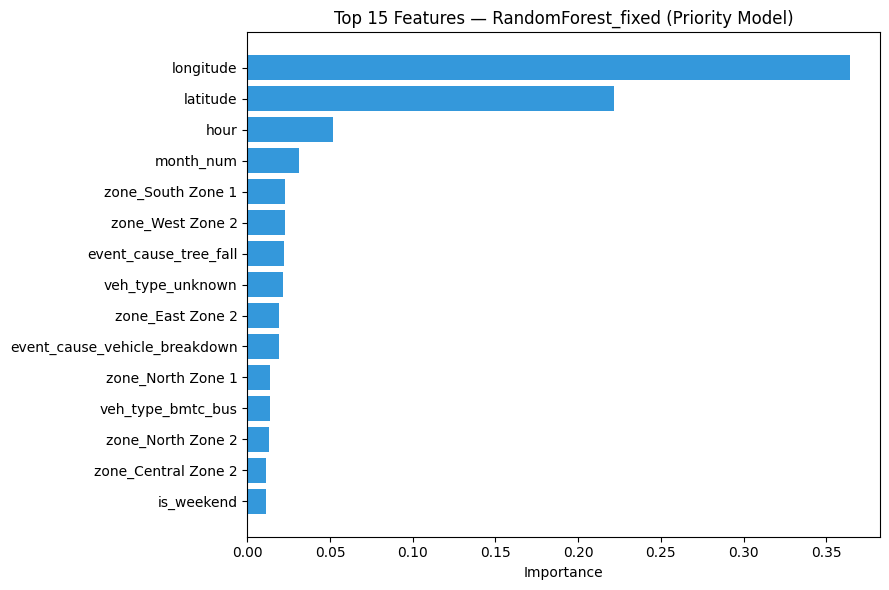

longitude                        0.364231
latitude                         0.221445
hour                             0.051930
month_num                        0.031421
zone_South Zone 1                0.022978
zone_West Zone 2                 0.022519
event_cause_tree_fall            0.022344
veh_type_unknown                 0.021260
zone_East Zone 2                 0.019362
event_cause_vehicle_breakdown    0.018976
zone_North Zone 1                0.013982
veh_type_bmtc_bus                0.013636
zone_North Zone 2                0.013342
zone_Central Zone 2              0.011373
is_weekend                       0.011237


In [130]:
print("=" * 65)
print("FEATURE IMPORTANCE — Priority Classifier")
print("=" * 65)

if hasattr(best_priority_model, 'feature_importances_'):
    fi = pd.Series(best_priority_model.feature_importances_, index=priority_feature_cols)
    fi = fi.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi.index[::-1], fi.values[::-1], color='#3498db')
    ax.set_title(f'Top 15 Features — {best_priority_name} (Priority Model)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('model1_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(fi.to_string())
else:
    print("best_priority_model has no feature_importances_ attribute")

In [132]:
import joblib, os
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score

SAVE_DIR = '/content/drive/MyDrive/gridlock_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save models
joblib.dump(best_priority_model, f'{SAVE_DIR}/priority_classifier.pkl')
joblib.dump(best_closure_model,  f'{SAVE_DIR}/road_closure_classifier.pkl')
joblib.dump(reg_log,             f'{SAVE_DIR}/duration_regressor.pkl')

# Save feature schemas (each model needs its OWN list — they differ)
joblib.dump(priority_feature_cols, f'{SAVE_DIR}/priority_feature_columns.pkl')
joblib.dump(closure_feature_cols,  f'{SAVE_DIR}/closure_feature_columns.pkl')
joblib.dump(duration_feature_cols, f'{SAVE_DIR}/duration_feature_columns.pkl')
joblib.dump(best_threshold,        f'{SAVE_DIR}/closure_threshold.pkl')

print("=" * 65)
print("✅ ALL MODELS SAVED")
print("=" * 65)
print(f"Location: {SAVE_DIR}\n")

# Recompute metrics fresh, directly from the live model + its own test set
pred_p = best_priority_model.predict(X_test_f)
print(f"  priority_classifier.pkl       Acc={accuracy_score(y_test_f, pred_p):.4f}  "
      f"F1={f1_score(y_test_f, pred_p):.4f}")

pred_c = (best_closure_model.predict_proba(X_test_rc)[:, 1] >= best_threshold).astype(int)
print(f"  road_closure_classifier.pkl   Acc={accuracy_score(y_test_rc, pred_c):.4f}  "
      f"F1={f1_score(y_test_rc, pred_c):.4f}  (threshold={best_threshold:.3f})")

pred_d_log = reg_log.predict(X_test_r)
pred_d_hrs = np.expm1(pred_d_log)
actual_d_hrs = np.expm1(y_test_r)
print(f"  duration_regressor.pkl        MAE={mean_absolute_error(actual_d_hrs, pred_d_hrs):.2f}hrs  "
      f"R²(log)={r2_score(y_test_r, pred_d_log):.4f}")

✅ ALL MODELS SAVED
Location: /content/drive/MyDrive/gridlock_models

  priority_classifier.pkl       Acc=0.7697  F1=0.8171
  road_closure_classifier.pkl   Acc=0.9080  F1=0.3951  (threshold=0.567)
  duration_regressor.pkl        MAE=1.11hrs  R²(log)=0.1967


In [133]:
# Cell — Capture the exact feature columns each model expects
print("=" * 65)
print("CAPTURING MODEL FEATURE SCHEMAS")
print("=" * 65)

priority_feature_cols = list(X_fixed.columns)      # from the priority fix cell (no corridor)
closure_feature_cols  = list(X_train_rc.columns)    # original, includes corridor
duration_feature_cols = list(X_reg.columns)         # original, includes corridor + severity_index

print(f"Priority model expects {len(priority_feature_cols)} features")
print(f"Closure model expects  {len(closure_feature_cols)} features")
print(f"Duration model expects {len(duration_feature_cols)} features")

CAPTURING MODEL FEATURE SCHEMAS
Priority model expects 47 features
Closure model expects  69 features
Duration model expects 66 features


In [134]:
def encode_single_event(event_dict, cat_cols, num_cols, target_columns, extra_numeric=None):
    """
    A single new event won't have every category present, so pd.get_dummies()
    on one row alone produces the wrong columns. We build the row, one-hot encode it,
    then reindex against the EXACT columns the trained model saw — missing
    categories become 0, which is the correct behavior.
    """
    row = {c: event_dict.get(c) for c in cat_cols + num_cols}
    if extra_numeric:
        row.update(extra_numeric)
    row_df = pd.DataFrame([row])
    encoded = pd.get_dummies(row_df, columns=cat_cols)
    encoded = encoded.reindex(columns=target_columns, fill_value=0)
    return encoded

In [135]:
print("=" * 65)
print("BUILDING POLICE STATION LOOKUP")
print("=" * 65)

# Historical mode: most common station per zone
zone_station_map = (
    temp_df.dropna(subset=['zone', 'police_station'])
    .groupby('zone')['police_station']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
zone_station_map.pop('Unknown', None)  # 'Unknown' isn't a real zone — force GPS fallback for it

station_coords = temp_df.dropna(subset=['latitude', 'longitude', 'police_station'])[
    ['latitude', 'longitude', 'police_station']
]

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def nearest_police_station(lat, lon, k=5):
    d = haversine_km(lat, lon, station_coords['latitude'].values, station_coords['longitude'].values)
    idx = np.argsort(d)[:k]
    nearest = station_coords.iloc[idx]['police_station']
    return nearest.mode()[0], round(d[idx].mean(), 2)

print(f"Zone-based lookup covers {len(zone_station_map)} zones")
print(f"GPS fallback available using {len(station_coords)} historical points")

BUILDING POLICE STATION LOOKUP
Zone-based lookup covers 10 zones
GPS fallback available using 8120 historical points


In [136]:
cause_score_map = {
    'vip_movement':5, 'public_event':4, 'protest':4, 'procession':3,
    'construction':3, 'tree_fall':3, 'water_logging':3, 'debris':3,
    'road_conditions':2, 'congestion':2, 'accident':2, 'others':2,
    'vehicle_breakdown':1, 'pot_holes':1, 'fog / low visibility':1, 'test_demo':0
}
manpower_map = {2:1, 3:2, 4:2, 5:3, 6:4, 7:6, 8:8, 9:10, 10:12, 11:15}

def risk_bucket(score):
    if score <= 4: return 'Low'
    elif score <= 7: return 'Medium'
    elif score <= 9: return 'High'
    else: return 'Critical'

In [137]:
## Recommendation Engine
def recommend_resources(event):
    """
    event: dict with event_type, event_cause, latitude, longitude, hour,
           day_of_week (0=Mon..6=Sun), month_num, and optionally zone, veh_type, corridor.

    Pipeline order matters: priority and closure are predicted FIRST (from
    genuinely available signals), then used to ESTIMATE severity — never the
    true severity_index, since that requires ground truth we won't have for
    a new event.
    """
    event = event.copy()
    event.setdefault('zone', 'Unknown')
    event.setdefault('veh_type', 'unknown')
    event.setdefault('corridor', 'Non-corridor')
    event.setdefault('is_weekend', 1 if event.get('day_of_week', 0) in [5, 6] else 0)
    event.setdefault('is_peak_hour', 1 if event.get('hour') in [7,8,9,17,18,19,20] else 0)
    event.setdefault('is_night', 1 if (event.get('hour', 12) >= 22 or event.get('hour', 12) < 6) else 0)

    # 1. Priority
    X_p = encode_single_event(event, CAT_FEATURES_FIXED, NUM_FEATURES_FIXED, priority_feature_cols)
    prob_high = best_priority_model.predict_proba(X_p)[0][1]
    pred_priority = 'High' if prob_high >= 0.5 else 'Low'

    # 2. Road closure (tuned threshold)
    X_c = encode_single_event(event, CAT_FEATURES, NUM_FEATURES, closure_feature_cols)
    prob_closure = best_closure_model.predict_proba(X_c)[0][1]
    pred_closure = bool(prob_closure >= best_threshold)

    # 3. Estimated severity — from PREDICTIONS, not ground truth
    cause_w = cause_score_map.get(event['event_cause'], 1)
    type_w = 2 if event['event_type'] == 'planned' else 1
    priority_w = 2 if pred_priority == 'High' else 1
    closure_w = 2 if pred_closure else 0
    est_severity = cause_w + type_w + priority_w + closure_w

    # 4. Duration (uses estimated severity as input)
    X_d = encode_single_event(event, CAT_FEATURES, NUM_FEATURES, duration_feature_cols,
                               extra_numeric={'severity_index': est_severity})
    pred_dur_hrs = np.expm1(reg_log.predict(X_d)[0])

    # 5. Manpower + risk level
    officers = manpower_map.get(est_severity, max(1, est_severity - 1))
    risk = risk_bucket(est_severity)

    # 6. Police station — GPS fallback if zone is unknown or unmapped
    if event['zone'] != 'Unknown' and event['zone'] in zone_station_map:
        station = zone_station_map[event['zone']]
        method = f"historical mode for {event['zone']}"
    else:
        station, dist = nearest_police_station(event['latitude'], event['longitude'])
        method = f"nearest by GPS (~{dist} km)"

    return {
        'predicted_priority': pred_priority,
        'priority_confidence': round(prob_high if pred_priority == 'High' else 1 - prob_high, 3),
        'predicted_road_closure': pred_closure,
        'closure_probability': round(prob_closure, 3),
        'predicted_duration_hours': round(pred_dur_hrs, 2),
        'estimated_severity_score': est_severity,
        'risk_level': risk,
        'recommended_officers': officers,
        'recommend_barricading': pred_closure,
        'recommended_police_station': station,
        'station_assignment_method': method,
    }

In [138]:
def print_recommendation(event, result):
    print("=" * 65)
    print(f"INCOMING EVENT: {event['event_cause'].replace('_',' ').title()} "
          f"({event['event_type']}) @ ({event['latitude']:.4f}, {event['longitude']:.4f})")
    print("=" * 65)
    print(f"  Priority           : {result['predicted_priority']}  (confidence {result['priority_confidence']*100:.1f}%)")
    print(f"  Road Closure       : {'YES' if result['predicted_road_closure'] else 'No'}  (prob {result['closure_probability']*100:.1f}%)")
    print(f"  Expected Duration  : {result['predicted_duration_hours']} hours")
    print(f"  Risk Level         : {result['risk_level']}  (score {result['estimated_severity_score']}/11)")
    print(f"  >> Recommended Officers : {result['recommended_officers']}")
    print(f"  >> Barricading Needed   : {'YES' if result['recommend_barricading'] else 'No'}")
    print(f"  >> Deploy From          : {result['recommended_police_station']} ({result['station_assignment_method']})")
    print()

example_events = [
    {'event_type':'planned','event_cause':'vip_movement','latitude':12.9716,'longitude':77.5946,
     'zone':'Central Zone 1','hour':18,'day_of_week':2,'month_num':3,'corridor':'Bellary Road 1'},
    {'event_type':'unplanned','event_cause':'vehicle_breakdown','latitude':12.95,'longitude':77.62,
     'hour':2,'day_of_week':5,'month_num':1},
    {'event_type':'unplanned','event_cause':'protest','latitude':12.935,'longitude':77.611,
     'zone':'South Zone 1','hour':9,'day_of_week':1,'month_num':2,'corridor':'Hosur Road'},
]

print("=" * 65)
print("DEMO — RESOURCE RECOMMENDATION ENGINE")
print("=" * 65)
print()
for ev in example_events:
    result = recommend_resources(ev)
    print_recommendation(ev, result)

DEMO — RESOURCE RECOMMENDATION ENGINE

INCOMING EVENT: Vip Movement (planned) @ (12.9716, 77.5946)
  Priority           : High  (confidence 54.6%)
  Road Closure       : YES  (prob 59.0%)
  Expected Duration  : 1.63 hours
  Risk Level         : Critical  (score 11/11)
  >> Recommended Officers : 15
  >> Barricading Needed   : YES
  >> Deploy From          : Ashok Nagar (historical mode for Central Zone 1)

INCOMING EVENT: Vehicle Breakdown (unplanned) @ (12.9500, 77.6200)
  Priority           : High  (confidence 57.0%)
  Road Closure       : No  (prob 47.9%)
  Expected Duration  : 0.76 hours
  Risk Level         : Low  (score 4/11)
  >> Recommended Officers : 2
  >> Barricading Needed   : No
  >> Deploy From          : Adugodi (nearest by GPS (~0.19 km))

INCOMING EVENT: Protest (unplanned) @ (12.9350, 77.6110)
  Priority           : Low  (confidence 59.9%)
  Road Closure       : No  (prob 48.5%)
  Expected Duration  : 2.09 hours
  Risk Level         : Medium  (score 6/11)
  >> Recomme

In [139]:
import joblib, os

SAVE_DIR = '/content/drive/MyDrive/gridlock_models'
os.makedirs(SAVE_DIR, exist_ok=True)

bundle = {
    'priority_model': best_priority_model, 'priority_feature_cols': priority_feature_cols,
    'closure_model': best_closure_model, 'closure_feature_cols': closure_feature_cols,
    'closure_threshold': best_threshold,
    'duration_model': reg_log, 'duration_feature_cols': duration_feature_cols,
    'cat_features_fixed': CAT_FEATURES_FIXED, 'num_features_fixed': NUM_FEATURES_FIXED,
    'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
    'cause_score_map': cause_score_map, 'manpower_map': manpower_map,
    'zone_station_map': zone_station_map, 'station_coords': station_coords,
}
joblib.dump(bundle, f'{SAVE_DIR}/recommendation_engine_bundle.pkl')
print(f"✅ Saved -> {SAVE_DIR}/recommendation_engine_bundle.pkl")
print(f"   File size: {os.path.getsize(f'{SAVE_DIR}/recommendation_engine_bundle.pkl')/1024:.1f} KB")

✅ Saved -> /content/drive/MyDrive/gridlock_models/recommendation_engine_bundle.pkl
   File size: 17970.6 KB


In [140]:
print("=" * 65)
print("CORRIDOR AUTO-DETECTION (no longer need to know corridor names)")
print("=" * 65)

corridor_coords = temp_df.dropna(subset=['latitude','longitude','corridor'])[['latitude','longitude','corridor']]

def nearest_corridor(lat, lon, k=5):
    d = haversine_km(lat, lon, corridor_coords['latitude'].values, corridor_coords['longitude'].values)
    idx = np.argsort(d)[:k]
    nearest = corridor_coords.iloc[idx]['corridor']
    return nearest.mode()[0], round(d[idx].mean(), 3)

def recommend_resources(event):
    event = event.copy()
    event.setdefault('zone', 'Unknown')
    event.setdefault('veh_type', 'unknown')
    event.setdefault('is_weekend', 1 if event.get('day_of_week', 0) in [5, 6] else 0)
    event.setdefault('is_peak_hour', 1 if event.get('hour') in [7,8,9,17,18,19,20] else 0)
    event.setdefault('is_night', 1 if (event.get('hour', 12) >= 22 or event.get('hour', 12) < 6) else 0)

    # Auto-detect corridor from GPS if not explicitly given
    if 'corridor' not in event or event['corridor'] is None:
        event['corridor'], _ = nearest_corridor(event['latitude'], event['longitude'])

    X_p = encode_single_event(event, CAT_FEATURES_FIXED, NUM_FEATURES_FIXED, priority_feature_cols)
    prob_high = best_priority_model.predict_proba(X_p)[0][1]
    pred_priority = 'High' if prob_high >= 0.5 else 'Low'

    X_c = encode_single_event(event, CAT_FEATURES, NUM_FEATURES, closure_feature_cols)
    prob_closure = best_closure_model.predict_proba(X_c)[0][1]
    pred_closure = bool(prob_closure >= best_threshold)

    cause_w = cause_score_map.get(event['event_cause'], 1)
    type_w = 2 if event['event_type'] == 'planned' else 1
    priority_w = 2 if pred_priority == 'High' else 1
    closure_w = 2 if pred_closure else 0
    est_severity = cause_w + type_w + priority_w + closure_w

    X_d = encode_single_event(event, CAT_FEATURES, NUM_FEATURES, duration_feature_cols,
                               extra_numeric={'severity_index': est_severity})
    pred_dur_hrs = np.expm1(reg_log.predict(X_d)[0])

    officers = manpower_map.get(est_severity, max(1, est_severity - 1))
    risk = risk_bucket(est_severity)

    if event['zone'] != 'Unknown' and event['zone'] in zone_station_map:
        station = zone_station_map[event['zone']]
        method = f"historical mode for {event['zone']}"
    else:
        station, dist = nearest_police_station(event['latitude'], event['longitude'])
        method = f"nearest by GPS (~{dist} km)"

    return {
        'predicted_priority': pred_priority,
        'priority_confidence': round(prob_high if pred_priority == 'High' else 1 - prob_high, 3),
        'predicted_road_closure': pred_closure,
        'closure_probability': round(prob_closure, 3),
        'predicted_duration_hours': round(pred_dur_hrs, 2),
        'estimated_severity_score': est_severity,
        'risk_level': risk,
        'recommended_officers': officers,
        'recommend_barricading': pred_closure,
        'recommended_police_station': station,
        'station_assignment_method': method,
        'detected_corridor': event['corridor'],
    }

print("recommend_resources() updated — now only needs lat/long, event_type, event_cause, and time")

CORRIDOR AUTO-DETECTION (no longer need to know corridor names)
recommend_resources() updated — now only needs lat/long, event_type, event_cause, and time


In [146]:
bundle = {
    'priority_model': best_priority_model, 'priority_feature_cols': priority_feature_cols,
    'closure_model': best_closure_model, 'closure_feature_cols': closure_feature_cols,
    'closure_threshold': best_threshold,
    'duration_model': reg_log, 'duration_feature_cols': duration_feature_cols,
    'cat_features_fixed': CAT_FEATURES_FIXED, 'num_features_fixed': NUM_FEATURES_FIXED,
    'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
    'cause_score_map': cause_score_map, 'manpower_map': manpower_map,
    'zone_station_map': zone_station_map, 'station_coords': station_coords,
    'corridor_coords': corridor_coords,
}
joblib.dump(bundle, f'{SAVE_DIR}/recommendation_engine_bundle.pkl')
print(f"✅ Re-saved with corridor auto-detection -> {SAVE_DIR}/recommendation_engine_bundle.pkl")

✅ Re-saved with corridor auto-detection -> /content/drive/MyDrive/gridlock_models/recommendation_engine_bundle.pkl


In [148]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Bengaluru Event-Driven Congestion", page_icon="🚦", layout="wide")

@st.cache_resource
def load_bundle():
    return joblib.load('/content/drive/MyDrive/gridlock_models/recommendation_engine_bundle.pkl')

B = load_bundle()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def nearest_police_station(lat, lon, k=5):
    sc = B['station_coords']
    d = haversine_km(lat, lon, sc['latitude'].values, sc['longitude'].values)
    idx = np.argsort(d)[:k]
    return sc.iloc[idx]['police_station'].mode()[0], round(d[idx].mean(), 2)

def nearest_corridor(lat, lon, k=5):
    cc = B['corridor_coords']
    d = haversine_km(lat, lon, cc['latitude'].values, cc['longitude'].values)
    idx = np.argsort(d)[:k]
    return cc.iloc[idx]['corridor'].mode()[0]

def risk_bucket(score):
    if score <= 4: return 'Low'
    elif score <= 7: return 'Medium'
    elif score <= 9: return 'High'
    else: return 'Critical'

def encode_single_event(event_dict, cat_cols, num_cols, target_columns, extra_numeric=None):
    row = {c: event_dict.get(c) for c in cat_cols + num_cols}
    if extra_numeric: row.update(extra_numeric)
    row_df = pd.DataFrame([row])
    encoded = pd.get_dummies(row_df, columns=cat_cols)
    return encoded.reindex(columns=target_columns, fill_value=0)

def recommend_resources(event):
    event = event.copy()
    event.setdefault('zone', 'Unknown')
    event.setdefault('veh_type', 'unknown')
    event.setdefault('is_weekend', 1 if event.get('day_of_week', 0) in [5, 6] else 0)
    event.setdefault('is_peak_hour', 1 if event.get('hour') in [7,8,9,17,18,19,20] else 0)
    event.setdefault('is_night', 1 if (event.get('hour', 12) >= 22 or event.get('hour', 12) < 6) else 0)

    detected_corridor = nearest_corridor(event['latitude'], event['longitude'])
    event['corridor'] = detected_corridor

    Xp = encode_single_event(event, B['cat_features_fixed'], B['num_features_fixed'], B['priority_feature_cols'])
    prob_high = B['priority_model'].predict_proba(Xp)[0][1]
    pred_priority = 'High' if prob_high >= 0.5 else 'Low'

    Xc = encode_single_event(event, B['cat_features'], B['num_features'], B['closure_feature_cols'])
    prob_closure = B['closure_model'].predict_proba(Xc)[0][1]
    pred_closure = bool(prob_closure >= B['closure_threshold'])

    cause_w = B['cause_score_map'].get(event['event_cause'], 1)
    type_w = 2 if event['event_type'] == 'planned' else 1
    priority_w = 2 if pred_priority == 'High' else 1
    closure_w = 2 if pred_closure else 0
    est_severity = cause_w + type_w + priority_w + closure_w

    Xd = encode_single_event(event, B['cat_features'], B['num_features'], B['duration_feature_cols'],
                              extra_numeric={'severity_index': est_severity})
    pred_dur_hrs = np.expm1(B['duration_model'].predict(Xd)[0])

    officers = B['manpower_map'].get(est_severity, max(1, est_severity - 1))
    risk = risk_bucket(est_severity)

    if event['zone'] != 'Unknown' and event['zone'] in B['zone_station_map']:
        station = B['zone_station_map'][event['zone']]
        method = f"historical mode for {event['zone']}"
    else:
        station, dist = nearest_police_station(event['latitude'], event['longitude'])
        method = f"nearest by GPS (~{dist} km)"

    return {
        'predicted_priority': pred_priority,
        'priority_confidence': round(prob_high if pred_priority == 'High' else 1 - prob_high, 3),
        'predicted_road_closure': pred_closure,
        'closure_probability': round(prob_closure, 3),
        'predicted_duration_hours': round(pred_dur_hrs, 2),
        'estimated_severity_score': est_severity,
        'risk_level': risk,
        'recommended_officers': officers,
        'recommend_barricading': pred_closure,
        'recommended_police_station': station,
        'station_assignment_method': method,
        'detected_corridor': detected_corridor,
    }

RISK_COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Critical': '#922b21'}

def badge(text, color):
    return f'<span style="background:{color};color:white;padding:4px 14px;border-radius:14px;font-weight:600;">{text}</span>'

# ---------------- UI ----------------
st.title("🚦 Bengaluru Event-Driven Congestion — Response Recommender")
st.caption("Gridlock Hackathon 2.0 · Theme 2 · Predicts incident impact and recommends manpower, barricading, and station deployment")

col_form, col_result = st.columns([1, 1.4])

with col_form:
    st.subheader("Incoming Event")
    event_type = st.radio("Event Type", ["unplanned", "planned"], horizontal=True)
    event_cause = st.selectbox("Cause", list(B['cause_score_map'].keys()))
    lat = st.number_input("Latitude", value=12.9716, format="%.6f")
    lon = st.number_input("Longitude", value=77.5946, format="%.6f")
    c1, c2, c3 = st.columns(3)
    hour = c1.slider("Hour", 0, 23, 9)
    day_of_week = c2.selectbox("Day", list(range(7)),
                                format_func=lambda x: ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][x])
    month_num = c3.selectbox("Month", list(range(1,13)), index=2)
    zone = st.selectbox("Zone (optional — leave Unknown to auto-detect)",
                         ['Unknown'] + sorted(B['zone_station_map'].keys()))
    submit = st.button("🔍 Get Recommendation", type="primary", use_container_width=True)

with col_result:
    if submit:
        event = {'event_type': event_type, 'event_cause': event_cause,
                  'latitude': lat, 'longitude': lon, 'hour': hour,
                  'day_of_week': day_of_week, 'month_num': month_num, 'zone': zone}
        r = recommend_resources(event)

        st.subheader("Recommendation")
        m1, m2, m3, m4 = st.columns(4)
        m1.markdown("**Priority**<br>" + badge(r['predicted_priority'],
                    '#e74c3c' if r['predicted_priority']=='High' else '#3498db'), unsafe_allow_html=True)
        m2.markdown("**Road Closure**<br>" + badge('YES' if r['predicted_road_closure'] else 'No',
                    '#e74c3c' if r['predicted_road_closure'] else '#2ecc71'), unsafe_allow_html=True)
        m3.markdown("**Risk Level**<br>" + badge(r['risk_level'], RISK_COLORS[r['risk_level']]), unsafe_allow_html=True)
        m4.metric("Est. Duration", f"{r['predicted_duration_hours']} hrs")

        st.write("")
        d1, d2, d3 = st.columns(3)
        d1.metric("Recommended Officers", r['recommended_officers'])
        d2.metric("Barricading Needed", "Yes" if r['recommend_barricading'] else "No")
        d3.metric("Priority Confidence", f"{r['priority_confidence']*100:.0f}%")

        st.write("")
        st.markdown(f"**Deploy from:** {r['recommended_police_station']}  \n"
                    f"*({r['station_assignment_method']})*")
        st.markdown(f"**Detected corridor:** {r['detected_corridor']}")
        st.markdown(f"**Closure probability:** {r['closure_probability']*100:.1f}%  ·  "
                    f"**Severity score:** {r['estimated_severity_score']}/11")

        st.map(pd.DataFrame({'lat':[lat], 'lon':[lon]}), zoom=12)
    else:
        st.info("Fill in the event details and click **Get Recommendation**.")

Overwriting app.py


In [150]:
import os, shutil

STAGE = '/content/gridlock_submission'
for sub in ['app', 'models', 'assets']:
    os.makedirs(f'{STAGE}/{sub}', exist_ok=True)

ephemeral_files = {
    'app.py': 'app',
    'step2_distributions.png': 'assets',
    'step3_time_patterns.png': 'assets',
    'step4_severity.png': 'assets',
    'step5_corridors_zones.png': 'assets',
    'step5_zone_time_matrix.png': 'assets',
    'eda_extra1_planned_vs_unplanned.png': 'assets',
    'model1_confusion_matrix.png': 'assets',
    'model1_feature_importance.png': 'assets',
    'bengaluru_hotspot_map.html': 'assets',
}

for fname, dest in ephemeral_files.items():
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{STAGE}/{dest}/{fname}')
        print(f'  ✅ {fname}')
    else:
        print(f'  ⚠️  still missing: {fname}')

shutil.copy('/content/drive/MyDrive/gridlock_models/recommendation_engine_bundle.pkl', f'{STAGE}/models/recommendation_engine_bundle.pkl')
print('  ✅ recommendation_engine_bundle.pkl')

shutil.make_archive('/content/flipkart_submission_zip', 'zip', STAGE)
print("\n✅ Zipped -> /content/flipkart_submission_zip.zip")

  ✅ app.py
  ✅ step2_distributions.png
  ✅ step3_time_patterns.png
  ✅ step4_severity.png
  ✅ step5_corridors_zones.png
  ✅ step5_zone_time_matrix.png
  ✅ eda_extra1_planned_vs_unplanned.png
  ✅ model1_confusion_matrix.png
  ✅ model1_feature_importance.png
  ✅ bengaluru_hotspot_map.html
  ✅ recommendation_engine_bundle.pkl

✅ Zipped -> /content/flipkart_submission_zip.zip


In [149]:
from pyngrok import ngrok
import subprocess, time
NGROK_AUTHTOKEN = "3FLOLdGbTZTueTKU26pHlUWXBcD_56zv1Y6m65P1pxkBttGYX"
ngrok.set_auth_token(NGROK_AUTHTOKEN)
ngrok.kill()
subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false'
])
time.sleep(6)
public_url = ngrok.connect(8501)
print(f"🌐 Live demo: {public_url}")
print("Open this in Chrome for best results.")

🌐 Live demo: NgrokTunnel: "https://quickness-process-tinsel.ngrok-free.dev" -> "http://localhost:8501"
Open this in Chrome for best results.
